In [43]:
from IPython.display import Javascript, HTML, display

# ── Styling ──────────────────────────────────────────────────────────────
display(HTML("""
<style>
body,.jp-Notebook{font-family:'Segoe UI',Arial,sans-serif;background:#f7f9fc}
h1{color:#1a1a2e;font-size:2.4em;border-bottom:4px solid #4361ee;padding-bottom:10px}
h2{color:#16213e;font-size:1.8em;margin-top:40px;padding-left:12px;border-left:5px solid #4361ee}
h3{color:#0f3460;font-size:1.3em;margin-top:24px}
p,li{font-size:1.07em;line-height:1.75;color:#2d2d2d}
.callout{background:#eef2ff;border-left:5px solid #4361ee;padding:14px 18px;border-radius:6px;margin:18px 0}
.warning{background:#fff8e1;border-left:5px solid #f9a825;padding:14px 18px;border-radius:6px;margin:18px 0}
.success{background:#e8f5e9;border-left:5px solid #43a047;padding:14px 18px;border-radius:6px;margin:18px 0}
table{border-collapse:collapse;width:100%;margin:16px 0}
th{background:#4361ee;color:white;padding:10px 14px;text-align:left}
td{padding:8px 14px;border-bottom:1px solid #dde}
tr:nth-child(even){background:#f0f4ff}
code{background:#eef2ff;padding:2px 6px;border-radius:4px;font-size:0.93em}
</style>
"""))

# ── Toggle button (injected into main page context via Javascript()) ───────
display(Javascript("""
(function() {
    // Remove any stale button from a previous run
    var old = document.getElementById('mlp-toggle-btn');
    if (old) old.remove();

    var btn = document.createElement('button');
    btn.id  = 'mlp-toggle-btn';
    btn.textContent = 'Show Code';
    btn.style.cssText = [
        'position:fixed', 'top:70px', 'right:20px', 'z-index:99999',
        'background:#4361ee', 'color:white', 'border:none', 'border-radius:8px',
        'padding:10px 20px', 'font-size:14px', 'cursor:pointer',
        'box-shadow:0 4px 14px rgba(67,97,238,0.45)', 'font-family:sans-serif',
        'transition:background 0.2s'
    ].join(';');
    btn.onmouseover = function(){ btn.style.background='#3a0ca3'; };
    btn.onmouseout  = function(){ btn.style.background='#4361ee'; };

    var visible = false;

    function getCells() {
        // JupyterLab
        var lab = Array.from(
            document.querySelectorAll('.jp-CodeCell .jp-Cell-inputWrapper'));
        // Classic Jupyter / Notebook 6
        var classic = Array.from(
            document.querySelectorAll('.code_cell .input'));
        return lab.length ? lab : classic;
    }

    btn.onclick = function() {
        visible = !visible;
        getCells().forEach(function(c){
            c.style.display = visible ? '' : 'none';
        });
        btn.textContent = visible ? 'Hide Code' : 'Show Code';
    };

    document.body.appendChild(btn);

    // Hide all code cells after the notebook finishes rendering
    function hideOnReady() {
        var cells = getCells();
        if (cells.length > 0) {
            cells.forEach(function(c){ c.style.display = 'none'; });
        } else {
            setTimeout(hideOnReady, 400);
        }
    }
    setTimeout(hideOnReady, 800);
})();
"""))


<IPython.core.display.Javascript object>

# Machine Learning Pipeline  
## Exploratory Data Analysis and Target-Updated Feature Engineering  

### Student Name: Sedat Akel  
### Project Title: Near-Future Vessel Behavior Prediction from NOAA AIS Using Derived Motion Features

<div class="callout">
This EDA notebook has been rebuilt to match the latest preprocessing and training/evaluation pipeline.  
Because the full DS2 raw AIS file is slow for exploratory execution, this notebook uses <b>DS1</b> for the EDA run, while the final data-preparation, train/validation/test split, model training, and evaluation notebooks remain based on <b>DS2</b>.
</div>

<div class="callout">
The important target update is that <b>steady</b> is no longer treated as a residual/default class. It is now assigned only when there is positive evidence of stable moving behavior.
</div>


In [44]:
# =========================================================
# Imports, styling, and global configuration
# =========================================================
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Project paths
# EDA is intentionally run on DS1 for faster exploratory execution.
# Final preprocessing/training/evaluation remain on DS2.
EDA_DATASET_NAME = "DS1"
FINAL_MODEL_DATASET_NAME = "DS2"
DATA_PATH = Path(f"./Data/{EDA_DATASET_NAME}.csv")

# These folder names are intentionally aligned with the final DS2 preprocessing/training notebooks.
PREP_DIR = Path("./ais_ds2_prepared")
FINAL_DIR = PREP_DIR / "final"
BALANCED_DIR = PREP_DIR / "balanced_train"

# Raw AIS columns
MMSI_COL = "MMSI"
TIME_COL = "BaseDateTime"
SOG_COL = "SOG"
COG_COL = "COG"
LAT_COL = "LAT"
LON_COL = "LON"
HEADING_COL = "Heading"

# Slice-level design from the latest preprocessing notebook
SLICE_MINUTES = 10
MIN_MSGS_FOR_REPR = 1
N_LAGS = 3

# Target class order used by preprocessing/training
TARGET_COL = "target_class"
target_order = ["steady", "stop", "accelerate", "decelerate", "maneuver"]
target_map = {name: i for i, name in enumerate(target_order)}
id_to_label = {v: k for k, v in target_map.items()}

# Plot colors
BLUE = "#4C78A8"
ORANGE = "#F58518"
GREEN = "#54A24B"
RED = "#E45756"
PURPLE = "#B279A2"
GRAY = "#7F7F7F"

print("EDA dataset:", EDA_DATASET_NAME)
print("Final modeling dataset:", FINAL_MODEL_DATASET_NAME)
print("DATA_PATH:", DATA_PATH)
print("Expected final prepared folder:", FINAL_DIR)
print("Target classes:", target_map)


EDA dataset: DS1
Final modeling dataset: DS2
DATA_PATH: Data/DS1.csv
Expected final prepared folder: ais_ds2_prepared/final
Target classes: {'steady': 0, 'stop': 1, 'accelerate': 2, 'decelerate': 3, 'maneuver': 4}


---
# 1. Project Definition

## Project title  
**Near-Future Vessel Behavior Prediction from NOAA AIS Using Derived Motion Features**

## Problem overview  
This project predicts a vessel's **near-future behavior class** from recent AIS-based motion history.  
Instead of forecasting the next latitude/longitude point, the task is formulated as a **multi-class classification problem**.

The final target classes are:

| Class | Meaning |
|---|---|
| `steady` | Vessel is moving with stable speed and course |
| `stop` | Future movement indicates stopped or near-stopped behavior |
| `accelerate` | Future mean speed increases meaningfully relative to past mean speed |
| `decelerate` | Future mean speed decreases meaningfully relative to past mean speed |
| `maneuver` | Future course change indicates a substantial direction change |

## Dataset role in this notebook  
For practical runtime reasons, this EDA notebook uses **DS1** as the exploratory AIS dataset.  
The final modeling pipeline still uses **DS2** in the preprocessing and training/evaluation notebooks.  
Therefore, DS1-based counts and plots should be interpreted as exploratory evidence, not as the final model-training distribution.

## Important update from earlier EDA  
The earlier EDA used an initial target prototype where cruising/steady behavior was closer to a fallback class.  
The final pipeline changed this logic: **steady now requires positive evidence of stable moving behavior**.

This notebook therefore rebuilds the EDA around the current target construction logic instead of simply polishing the older EDA.


---
# 2. Data Collection

## 2.1 Data source  
The dataset was obtained from the NOAA Office for Coastal Management / MarineCadastre AIS data service.  
The data contains raw AIS position and movement messages for a selected maritime area and time interval.

## 2.2 Selected dataset for EDA  
This notebook uses the smaller DS1 AIS dataset for faster exploratory analysis:

```text
./Data/DS1.csv
```

## 2.3 Final modeling dataset  
The final data-preparation and training/evaluation notebooks continue to use DS2.  
This separation is acceptable because the EDA notebook focuses on understanding the AIS data structure, domain-specific quality issues, target-construction behavior, and feature-engineering logic.  
The final model metrics and train/validation/test distributions should be reported only from the DS2 preprocessing and training/evaluation notebooks.

## 2.4 Raw data role in the pipeline  
The raw AIS file is not directly model-ready. It must be transformed into a trajectory-aware dataset by:

1. parsing and cleaning AIS fields,
2. ordering observations by `MMSI` and timestamp,
3. aggregating raw AIS messages into 10-minute slices,
4. constructing future-behavior targets from past and future slice windows,
5. deriving leakage-safe current/past features for model training.


In [45]:
# =========================================================
# Load raw AIS data
# =========================================================
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Raw data file was not found at {DATA_PATH}. "
        f"Place {EDA_DATASET_NAME}.csv under ./Data/ before running this notebook."
    )

df_raw = pd.read_csv(DATA_PATH)

print("Raw dataset shape:", df_raw.shape)
print("\nFirst 10 columns:")
print(df_raw.columns[:10].tolist())

display(df_raw.head())


Raw dataset shape: (150616, 17)

First 10 columns:
['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'IMO', 'CallSign']


,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Status,Length,Width,Draft,Cargo,TransceiverClass
0,367429010,2023-01-07T14:43:42,29.33536,-92.06424,6.4,298.2,511.0,SEA HORSE,IMO8941157,WDF2534,30,NaN,24,7.0,NaN,NaN,B
1,367429010,2023-01-07T14:46:42,29.33817,-92.06958,6.6,297.9,511.0,SEA HORSE,IMO8941157,WDF2534,30,NaN,24,7.0,NaN,NaN,B
2,367429010,2023-01-07T14:49:42,29.34103,-92.07497,6.6,299.3,511.0,SEA HORSE,IMO8941157,WDF2534,30,NaN,24,7.0,NaN,NaN,B
3,367429010,2023-01-07T14:57:11,29.34477,-92.08989,6.7,274.1,511.0,SEA HORSE,IMO8941157,WDF2534,30,NaN,24,7.0,NaN,NaN,B
4,367568840,2023-01-04T04:08:51,29.35427,-91.69107,2.4,92.3,511.0,CHAD ANTHONY,NaN,WDG7592,30,NaN,21,NaN,NaN,NaN,B


---
# 3. Evaluating the Raw AIS Data

## Goal of this section  
The goal is to understand the raw AIS messages before target construction and feature engineering.  
For this project, EDA must pay special attention to:

- AIS-specific placeholder values,
- irregular temporal spacing between messages,
- low-speed and stopped vessels,
- circular direction variables such as COG,
- whether raw fields are suitable for downstream derived features.


## 3.1 Schema and completeness check


In [46]:
# =========================================================
# Schema, data types, and missing values
# =========================================================
print("Dataset shape:", df_raw.shape)

print("\nColumn names:")
print(list(df_raw.columns))

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

missing = (
    df_raw.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df_raw) * 100).round(3))
    .sort_values("missing_count", ascending=False)
)

print("\nMissing values:")
display(missing)


Dataset shape: (150616, 17)

Column names:
['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo', 'TransceiverClass']

Data types:


,dtype
MMSI,int64
BaseDateTime,str
LAT,float64
LON,float64
SOG,float64
COG,float64
Heading,float64
VesselName,str
IMO,str
CallSign,str



Missing values:


,missing_count,missing_pct
Draft,111940,74.321
IMO,104769,69.560
Cargo,59397,39.436
Status,59397,39.436
Width,4640,3.081
CallSign,143,0.095
Length,0,0.000
VesselType,0,0.000
MMSI,0,0.000
BaseDateTime,0,0.000


## 3.2 Descriptive statistics

The main raw motion variables are:

- `SOG`: Speed over ground  
- `COG`: Course over ground  
- `Heading`: vessel heading, where `511` is an AIS placeholder for unknown heading  
- `LAT`, `LON`: position coordinates


In [47]:
# =========================================================
# Descriptive statistics for key AIS fields
# =========================================================
key_cols = [c for c in [SOG_COL, COG_COL, HEADING_COL, LAT_COL, LON_COL] if c in df_raw.columns]

numeric_view = df_raw[key_cols].apply(pd.to_numeric, errors="coerce")
display(numeric_view.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

# Quick dataset summary
summary = {
    "rows": len(df_raw),
    "columns": df_raw.shape[1],
    "unique_mmsi": df_raw[MMSI_COL].nunique() if MMSI_COL in df_raw.columns else np.nan,
}
if TIME_COL in df_raw.columns:
    ts = pd.to_datetime(df_raw[TIME_COL], errors="coerce")
    summary["min_timestamp"] = ts.min()
    summary["max_timestamp"] = ts.max()

display(pd.Series(summary).to_frame("value"))


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
SOG,150616.0,3.332822,4.965180,0.00000,0.000000,0.00000,0.100000,1.800000,3.00000,16.200000,19.800000,102.30000
COG,150616.0,211.133013,111.952905,0.00000,4.800000,25.10000,108.500000,225.800000,307.20000,360.000000,360.000000,360.00000
Heading,150616.0,507.516426,36.611699,0.00000,511.000000,511.00000,511.000000,511.000000,511.00000,511.000000,511.000000,511.00000
LAT,150616.0,29.399790,0.067332,29.27666,29.284982,29.30393,29.341137,29.389575,29.44633,29.493170,29.616171,29.63006
LON,150616.0,-91.944761,0.144814,-92.20114,-92.188859,-92.13260,-92.066390,-91.992595,-91.81923,-91.690777,-91.645471,-91.63476


,value
rows,150616
columns,17
unique_mmsi,52
min_timestamp,2022-12-31 00:00:04
max_timestamp,2023-01-30 23:59:54


## 3.3 Raw feature distributions


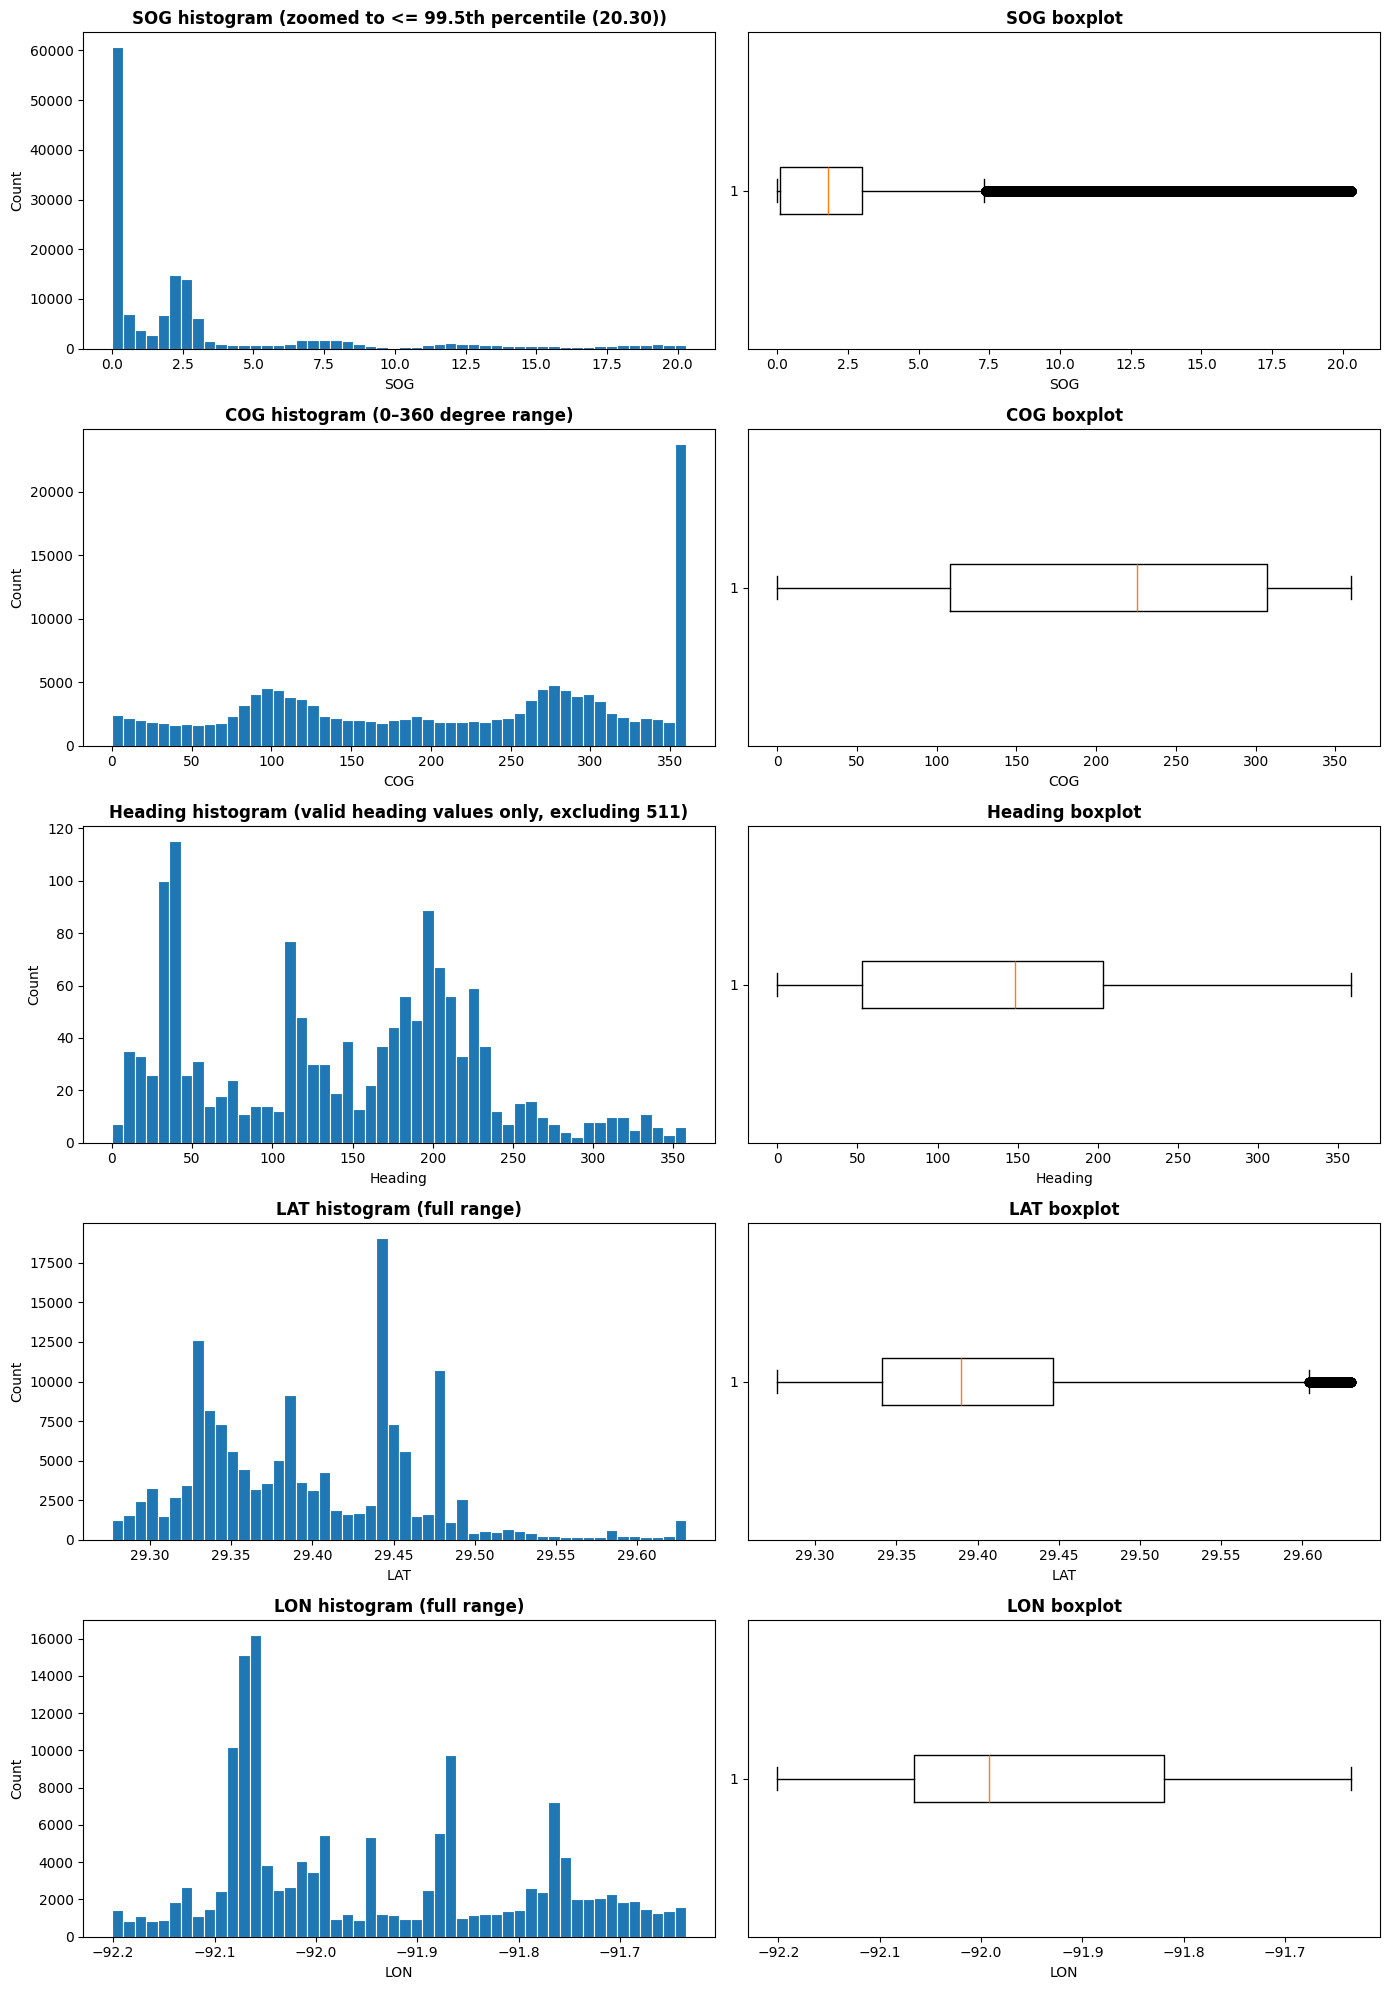

In [48]:
# =========================================================
# Raw feature distributions
# =========================================================
feature_cols_raw = [c for c in [SOG_COL, COG_COL, HEADING_COL, LAT_COL, LON_COL] if c in df_raw.columns]

plot_df = df_raw[feature_cols_raw].copy()
for col in feature_cols_raw:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

n_features = len(feature_cols_raw)
fig, axes = plt.subplots(n_features, 2, figsize=(14, 4 * n_features))

if n_features == 1:
    axes = np.array([axes])

for i, col in enumerate(feature_cols_raw):
    values = plot_df[col].dropna()

    # For Heading, show valid heading separately from the unknown placeholder 511.
    if col == HEADING_COL:
        values_for_hist = values[values <= 360]
        box_values = values_for_hist
        subtitle = "valid heading values only, excluding 511"
    elif col == COG_COL:
        values_for_hist = values[(values >= 0) & (values <= 360)]
        box_values = values_for_hist
        subtitle = "0–360 degree range"
    elif col == SOG_COL:
        upper = values.quantile(0.995)
        values_for_hist = values[values <= upper]
        box_values = values_for_hist
        subtitle = f"zoomed to <= 99.5th percentile ({upper:.2f})"
    else:
        values_for_hist = values
        box_values = values
        subtitle = "full range"

    axes[i, 0].hist(values_for_hist, bins=50, edgecolor="white", linewidth=0.8)
    axes[i, 0].set_title(f"{col} histogram ({subtitle})", fontweight="bold")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Count")

    axes[i, 1].boxplot(box_values.dropna(), vert=False)
    axes[i, 1].set_title(f"{col} boxplot", fontweight="bold")
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()


### Raw distribution interpretation

The executed DS1 run confirms typical AIS trajectory characteristics:

- `SOG` is right-skewed. The median speed is about **1.8 knots**, while the 95th percentile is **16.2 knots**. This supports treating stopped/low-speed behavior separately from moving behavior.
- `COG` is circular and also contains a large suspicious boundary concentration at **360 degrees**. The later preprocessing step therefore removes `COG = 360` before course-change features are derived.
- `Heading` should not be interpreted as a normal numeric angle in this dataset. In the DS1 run, **149,193 of 150,616 rows** have `Heading = 511`, which is the AIS placeholder for unknown heading.
- `LAT` and `LON` describe the selected geographic region and route structure. They are useful for understanding the dataset scope, but the final model focuses mainly on derived motion features rather than raw identity/location fields.


## 3.4 AIS-specific data quality investigations


In [49]:
# =========================================================
# AIS-specific quality audit
# =========================================================
audit_rows = []

if HEADING_COL in df_raw.columns:
    heading = pd.to_numeric(df_raw[HEADING_COL], errors="coerce")
    audit_rows.extend([
        {"issue": "Heading == 511 placeholder", "count": int((heading == 511).sum())},
        {"issue": "Heading valid 0–360", "count": int(((heading >= 0) & (heading <= 360)).sum())},
        {"issue": "Heading missing/non-numeric", "count": int(heading.isna().sum())},
    ])

if COG_COL in df_raw.columns:
    cog = pd.to_numeric(df_raw[COG_COL], errors="coerce")
    audit_rows.extend([
        {"issue": "COG == 360 suspicious boundary value", "count": int((cog == 360).sum())},
        {"issue": "COG outside 0–360", "count": int(((cog < 0) | (cog > 360)).sum())},
        {"issue": "COG missing/non-numeric", "count": int(cog.isna().sum())},
    ])

if SOG_COL in df_raw.columns:
    sog = pd.to_numeric(df_raw[SOG_COL], errors="coerce")
    audit_rows.extend([
        {"issue": "SOG < 0", "count": int((sog < 0).sum())},
        {"issue": "SOG > 30 knots", "count": int((sog > 30).sum())},
        {"issue": "SOG missing/non-numeric", "count": int(sog.isna().sum())},
    ])

audit_df = pd.DataFrame(audit_rows)
audit_df["pct_of_rows"] = (audit_df["count"] / len(df_raw) * 100).round(3)
display(audit_df)

# Show examples of the most important AIS placeholder issue.
if HEADING_COL in df_raw.columns:
    example_cols = [c for c in [MMSI_COL, TIME_COL, LAT_COL, LON_COL, SOG_COL, COG_COL, HEADING_COL] if c in df_raw.columns]
    print("\nExamples where Heading == 511:")
    display(df_raw.loc[pd.to_numeric(df_raw[HEADING_COL], errors="coerce") == 511, example_cols].head(10))


,issue,count,pct_of_rows
0,Heading == 511 placeholder,149193,99.055
1,Heading valid 0–360,1423,0.945
2,Heading missing/non-numeric,0,0.000
3,COG == 360 suspicious boundary value,21615,14.351
4,COG outside 0–360,0,0.000
5,COG missing/non-numeric,0,0.000
6,SOG < 0,0,0.000
7,SOG > 30 knots,1,0.001
8,SOG missing/non-numeric,0,0.000



Examples where Heading == 511:


,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading
0,367429010,2023-01-07T14:43:42,29.33536,-92.06424,6.4,298.2,511.0
1,367429010,2023-01-07T14:46:42,29.33817,-92.06958,6.6,297.9,511.0
2,367429010,2023-01-07T14:49:42,29.34103,-92.07497,6.6,299.3,511.0
3,367429010,2023-01-07T14:57:11,29.34477,-92.08989,6.7,274.1,511.0
4,367568840,2023-01-04T04:08:51,29.35427,-91.69107,2.4,92.3,511.0
5,367568840,2023-01-04T04:28:23,29.35405,-91.67695,2.3,88.5,511.0
6,367568840,2023-01-04T04:29:53,29.35409,-91.67585,2.3,88.4,511.0
7,367568840,2023-01-04T04:31:51,29.35411,-91.67441,2.5,87.8,511.0
8,367568840,2023-01-04T04:33:22,29.35411,-91.67328,2.3,96.1,511.0
9,367568840,2023-01-04T04:34:51,29.35411,-91.67218,2.3,96.1,511.0


### Data-quality decisions used later

The final preprocessing notebook applies these domain-specific decisions:

| Issue | Decision |
|---|---|
| `Heading = 511` | Treat as unknown heading, not as a true angle |
| Invalid negative `SOG` | Convert to missing |
| Invalid `COG` outside 0–360 | Convert to missing |
| `COG = 360` | Remove because it behaved like a suspicious/low-information boundary value in this dataset |
| Low-speed COG instability | Mask COG/turn-derived model features when speed is too low and keep a `cog_reliable` indicator |


## 3.5 Temporal continuity and raw trajectory ordering


,time_gap_sec
count,1.505640e+05
mean,2.871283e+02
std,1.062248e+04
min,0.000000e+00
25%,6.900000e+01
50%,7.200000e+01
75%,9.100000e+01
90%,1.800000e+02
95%,2.060000e+02
99%,5.410000e+02


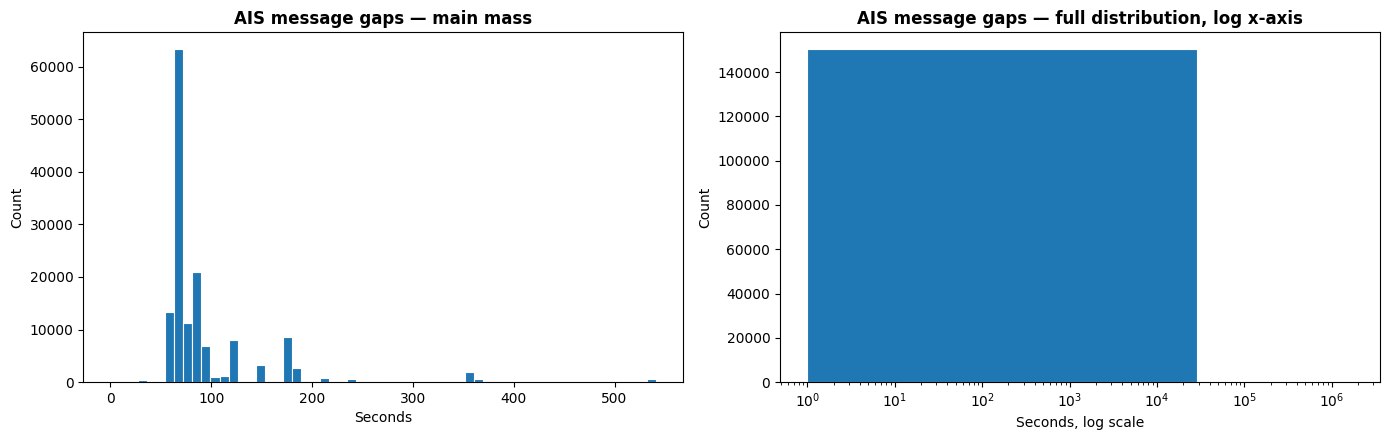

In [50]:
# =========================================================
# Timestamp parsing and AIS message gap analysis
# =========================================================
df_time = df_raw.copy()
df_time[TIME_COL] = pd.to_datetime(df_time[TIME_COL], errors="coerce")
df_time[MMSI_COL] = pd.to_numeric(df_time[MMSI_COL], errors="coerce")

for col in [SOG_COL, COG_COL, HEADING_COL, LAT_COL, LON_COL]:
    if col in df_time.columns:
        df_time[col] = pd.to_numeric(df_time[col], errors="coerce")

df_time = (
    df_time
    .dropna(subset=[MMSI_COL, TIME_COL])
    .sort_values([MMSI_COL, TIME_COL])
    .reset_index(drop=True)
)

df_time["time_gap_sec"] = df_time.groupby(MMSI_COL)[TIME_COL].diff().dt.total_seconds()

gap = df_time["time_gap_sec"].dropna()
display(gap.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).to_frame("time_gap_sec"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

if len(gap) > 0:
    upper_main = gap.quantile(0.99)
    axes[0].hist(gap[gap <= upper_main], bins=60, edgecolor="white", linewidth=0.8)
    axes[0].set_title("AIS message gaps — main mass", fontweight="bold")
    axes[0].set_xlabel("Seconds")
    axes[0].set_ylabel("Count")

    gap_positive = gap[gap > 0]
    axes[1].hist(gap_positive, bins=60, edgecolor="white", linewidth=0.8)
    axes[1].set_xscale("log")
    axes[1].set_title("AIS message gaps — full distribution, log x-axis", fontweight="bold")
    axes[1].set_xlabel("Seconds, log scale")
    axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


### Temporal continuity interpretation

AIS messages are trajectory data, not independent tabular rows.  
In the DS1 run, the median message gap is about **72 seconds**, but the maximum gap is much larger because vessels can disappear and later reappear in the AIS feed.

This supports the later transformation into fixed **10-minute vessel-level slices**.  
The slice representation reduces sensitivity to irregular reporting intervals and creates a consistent unit for target construction and feature engineering.


---
# 4. Slice-Level Trajectory Representation

The latest preprocessing pipeline does not train directly on raw AIS messages.  
It first converts each vessel track into a **10-minute slice-level representation**.

For each `MMSI` and 10-minute slice, the pipeline stores:

- number of AIS messages in the slice,
- first and last timestamp,
- representative speed (`rep_sog`, median SOG),
- SOG summary statistics,
- representative course (`rep_cog`, circular mean COG),
- circular COG variability,
- whether the slice has enough data for representation.

Empty slices are preserved in the vessel timeline so that future/past windows can detect gaps.


In [51]:
# =========================================================
# Helper functions: circular statistics, cleaning, and slicing
# =========================================================

def circular_mean_deg(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.nan

    rad = np.deg2rad(arr)
    sin_mean = np.mean(np.sin(rad))
    cos_mean = np.mean(np.cos(rad))

    if np.isclose(sin_mean, 0.0) and np.isclose(cos_mean, 0.0):
        return np.nan

    return np.rad2deg(np.arctan2(sin_mean, cos_mean)) % 360


def circular_std_deg(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.nan

    rad = np.deg2rad(arr)
    sin_mean = np.mean(np.sin(rad))
    cos_mean = np.mean(np.cos(rad))
    r = np.sqrt(sin_mean**2 + cos_mean**2)

    if r <= 0:
        return np.nan

    return np.rad2deg(np.sqrt(-2 * np.log(r)))


def circular_diff_scalar_deg(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan
    return ((a - b + 180) % 360) - 180


def circular_diff_series_deg(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    out = ((a - b + 180) % 360) - 180
    out[np.isnan(a) | np.isnan(b)] = np.nan
    return out


def clean_ais_df(df):
    """Clean raw AIS rows using the same core decisions as the final preprocessing notebook."""
    df = df.copy()

    required_cols = [MMSI_COL, TIME_COL, SOG_COL, COG_COL]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
    df[MMSI_COL] = pd.to_numeric(df[MMSI_COL], errors="coerce")
    df[SOG_COL] = pd.to_numeric(df[SOG_COL], errors="coerce")
    df[COG_COL] = pd.to_numeric(df[COG_COL], errors="coerce")

    df = df.dropna(subset=[MMSI_COL, TIME_COL]).copy()
    df[MMSI_COL] = df[MMSI_COL].astype("int64")

    # Basic physical validity
    df.loc[df[SOG_COL] < 0, SOG_COL] = np.nan
    df.loc[(df[COG_COL] < 0) | (df[COG_COL] > 360), COG_COL] = np.nan

    # Final preprocessing decision: remove suspicious COG == 360 rows.
    df = df[df[COG_COL] != 360].copy()

    return df


def build_full_slice_grid_for_vessel(g, slice_freq):
    mmsi = g.name

    full_index = pd.date_range(
        start=g["slice_start"].min(),
        end=g["slice_start"].max(),
        freq=slice_freq
    )

    full = pd.DataFrame({
        MMSI_COL: mmsi,
        "slice_start": full_index
    })

    return full.merge(
        g.drop(columns=[MMSI_COL], errors="ignore"),
        on="slice_start",
        how="left"
    )


def build_slice_level_for_df(raw_df):
    """Convert cleaned AIS rows into global-clock-aligned 10-minute vessel slices."""
    ais_slice_df = clean_ais_df(raw_df)

    if ais_slice_df.empty:
        return pd.DataFrame()

    slice_freq = f"{SLICE_MINUTES}min"
    ais_slice_df = ais_slice_df.sort_values([MMSI_COL, TIME_COL]).copy()

    ais_slice_df["slice_start"] = ais_slice_df[TIME_COL].dt.floor(slice_freq)
    ais_slice_df["slice_end"] = ais_slice_df["slice_start"] + pd.Timedelta(minutes=SLICE_MINUTES)

    agg_df = (
        ais_slice_df
        .groupby([MMSI_COL, "slice_start"], as_index=False)
        .agg(
            n_msgs=(TIME_COL, "size"),
            first_ts_in_slice=(TIME_COL, "min"),
            last_ts_in_slice=(TIME_COL, "max"),

            rep_sog=(SOG_COL, "median"),
            sog_mean=(SOG_COL, "mean"),
            sog_std=(SOG_COL, "std"),
            sog_min=(SOG_COL, "min"),
            sog_max=(SOG_COL, "max"),

            rep_cog=(COG_COL, lambda x: circular_mean_deg(x)),
            cog_circular_std=(COG_COL, lambda x: circular_std_deg(x)),
        )
    )

    agg_df["slice_end"] = agg_df["slice_start"] + pd.Timedelta(minutes=SLICE_MINUTES)
    agg_df["coverage_seconds"] = (
        agg_df["last_ts_in_slice"] - agg_df["first_ts_in_slice"]
    ).dt.total_seconds()

    full_grid_df = (
        agg_df
        .groupby(MMSI_COL, group_keys=False)
        .apply(lambda g: build_full_slice_grid_for_vessel(g, slice_freq))
        .reset_index(drop=True)
    )

    full_grid_df["slice_end"] = full_grid_df["slice_start"] + pd.Timedelta(minutes=SLICE_MINUTES)

    slice_level_df = full_grid_df.copy()
    slice_level_df["has_data"] = slice_level_df["n_msgs"].notna()
    slice_level_df["n_msgs"] = slice_level_df["n_msgs"].fillna(0).astype(int)
    slice_level_df["enough_data_for_repr"] = slice_level_df["n_msgs"] >= MIN_MSGS_FOR_REPR

    slice_level_df["cog_valid_for_maneuver"] = (
        slice_level_df["has_data"] &
        slice_level_df["rep_cog"].notna() &
        slice_level_df["rep_sog"].notna() &
        (slice_level_df["rep_sog"] >= 1.0)
    )

    return slice_level_df.sort_values([MMSI_COL, "slice_start"]).reset_index(drop=True)


In [52]:
# =========================================================
# Build slice-level dataframe
# =========================================================
slice_level_df = build_slice_level_for_df(df_raw)
slice_level_df = slice_level_df.sort_values([MMSI_COL, "slice_start"]).reset_index(drop=True)

print("slice_level_df:", slice_level_df.shape)
print("Unique MMSIs:", slice_level_df[MMSI_COL].nunique())
print("Empty slice ratio:", round((~slice_level_df["has_data"]).mean(), 4))

display(slice_level_df.head(15))

slice_summary = pd.DataFrame({
    "metric": [
        "raw AIS rows",
        "slice-level rows",
        "unique MMSIs",
        "slices with data",
        "empty slices",
        "empty slice ratio",
    ],
    "value": [
        len(df_raw),
        len(slice_level_df),
        slice_level_df[MMSI_COL].nunique(),
        int(slice_level_df["has_data"].sum()),
        int((~slice_level_df["has_data"]).sum()),
        round((~slice_level_df["has_data"]).mean(), 4),
    ]
})
display(slice_summary)


slice_level_df: (72101, 17)
Unique MMSIs: 52
Empty slice ratio: 0.6718


,MMSI,slice_start,n_msgs,first_ts_in_slice,last_ts_in_slice,rep_sog,sog_mean,sog_std,sog_min,sog_max,rep_cog,cog_circular_std,slice_end,coverage_seconds,has_data,enough_data_for_repr,cog_valid_for_maneuver
0,338115852,2023-01-10 19:50:00,4,2023-01-10 19:53:05,2023-01-10 19:58:06,8.00,8.000000,0.182574,7.8,8.2,306.556167,8.117313,2023-01-10 20:00:00,301.0,True,True,True
1,338115852,2023-01-10 20:00:00,6,2023-01-10 20:01:04,2023-01-10 20:07:36,8.15,8.166667,0.320416,7.8,8.7,292.250015,1.448909,2023-01-10 20:10:00,392.0,True,True,True
2,338115852,2023-01-10 20:10:00,6,2023-01-10 20:10:05,2023-01-10 20:19:35,8.10,8.000000,0.219089,7.6,8.2,292.966160,2.877112,2023-01-10 20:20:00,570.0,True,True,True
3,338115852,2023-01-10 20:20:00,5,2023-01-10 20:21:04,2023-01-10 20:28:33,7.80,7.760000,0.151658,7.5,7.9,293.541174,2.830389,2023-01-10 20:30:00,449.0,True,True,True
4,338115852,2023-01-10 20:30:00,7,2023-01-10 20:30:04,2023-01-10 20:39:32,7.50,7.528571,0.188982,7.2,7.8,292.014469,2.905583,2023-01-10 20:40:00,568.0,True,True,True
5,338115852,2023-01-10 20:40:00,7,2023-01-10 20:40:33,2023-01-10 20:49:32,7.40,7.442857,0.257275,7.0,7.8,290.399866,1.737884,2023-01-10 20:50:00,539.0,True,True,True
6,338115852,2023-01-10 20:50:00,7,2023-01-10 20:50:34,2023-01-10 20:59:32,7.40,7.385714,0.323669,6.8,7.9,291.494585,5.385720,2023-01-10 21:00:00,538.0,True,True,True
7,338115852,2023-01-10 21:00:00,6,2023-01-10 21:00:32,2023-01-10 21:09:31,7.45,7.466667,0.273252,7.1,7.8,300.484374,3.225236,2023-01-10 21:10:00,539.0,True,True,True
8,338115852,2023-01-10 21:10:00,4,2023-01-10 21:12:30,2023-01-10 21:18:31,7.55,7.575000,0.170783,7.4,7.8,297.945609,4.933292,2023-01-10 21:20:00,361.0,True,True,True
9,338115852,2023-01-10 21:20:00,6,2023-01-10 21:20:00,2023-01-10 21:29:29,7.35,7.366667,0.216025,7.1,7.7,292.199615,3.036840,2023-01-10 21:30:00,569.0,True,True,True


,metric,value
0,raw AIS rows,150616.0000
1,slice-level rows,72101.0000
2,unique MMSIs,52.0000
3,slices with data,23666.0000
4,empty slices,48435.0000
5,empty slice ratio,0.6718


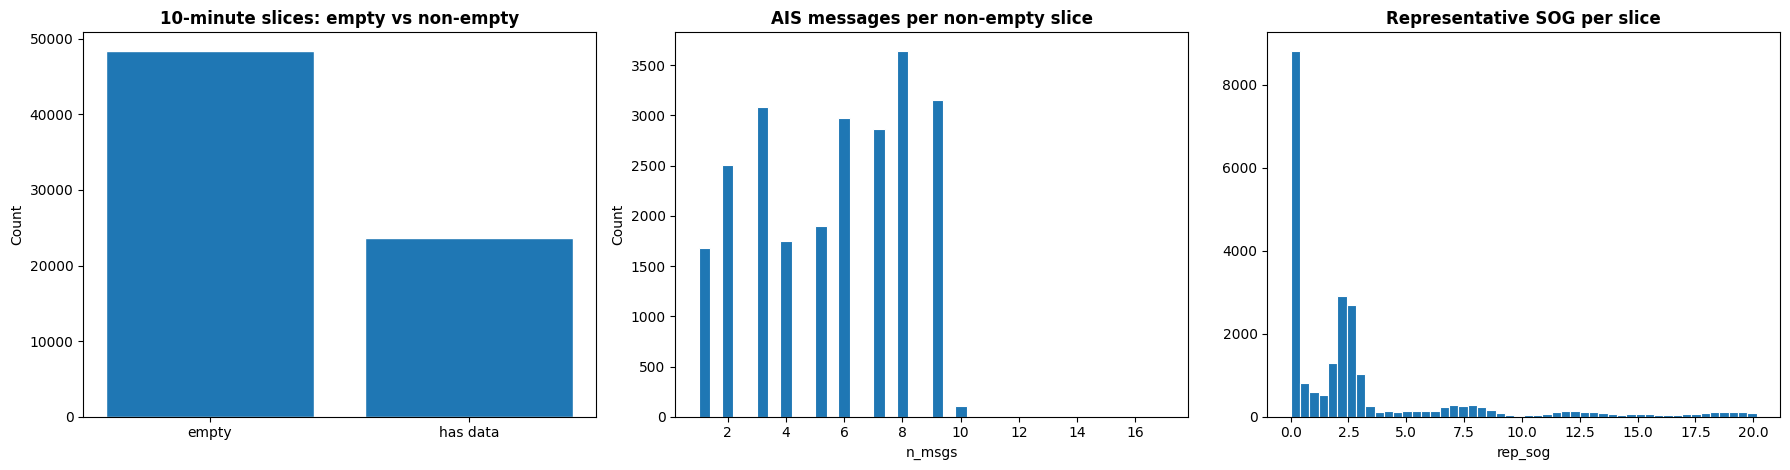

,count,mean,std,min,25%,50%,75%,max
n_msgs,23666.0,5.450900,2.595885,1.000000,3.000000,6.000000,8.00000,17.000000
rep_sog,23666.0,3.146778,4.607520,0.000000,0.150000,2.000000,2.90000,22.300000
sog_mean,23666.0,3.149156,4.428687,0.000000,0.166667,2.057143,2.95000,22.300000
sog_std,21987.0,0.574326,1.457834,0.000000,0.057735,0.120185,0.28200,11.106004
rep_cog,23662.0,187.678460,101.752022,0.015706,100.568835,189.900000,278.87957,359.978573
cog_circular_std,23666.0,30.487409,37.774270,-0.000000,2.929961,9.047487,56.56147,489.129120
coverage_seconds,23666.0,419.874461,163.140763,0.000000,360.000000,488.000000,539.00000,599.000000


In [53]:
# =========================================================
# Slice-level EDA plots
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

has_data_counts = slice_level_df["has_data"].value_counts().sort_index()
axes[0].bar(["empty", "has data"], [has_data_counts.get(False, 0), has_data_counts.get(True, 0)], edgecolor="white")
axes[0].set_title("10-minute slices: empty vs non-empty", fontweight="bold")
axes[0].set_ylabel("Count")

nonempty = slice_level_df[slice_level_df["has_data"]].copy()

axes[1].hist(nonempty["n_msgs"], bins=40, edgecolor="white", linewidth=0.8)
axes[1].set_title("AIS messages per non-empty slice", fontweight="bold")
axes[1].set_xlabel("n_msgs")
axes[1].set_ylabel("Count")

upper_sog = nonempty["rep_sog"].quantile(0.995)
axes[2].hist(nonempty.loc[nonempty["rep_sog"] <= upper_sog, "rep_sog"], bins=50, edgecolor="white", linewidth=0.8)
axes[2].set_title("Representative SOG per slice", fontweight="bold")
axes[2].set_xlabel("rep_sog")

plt.tight_layout()
plt.show()

display(nonempty[["n_msgs", "rep_sog", "sog_mean", "sog_std", "rep_cog", "cog_circular_std", "coverage_seconds"]].describe().T)


### Slice-level representation interpretation

The DS1 run created **72,101** 10-minute vessel-slice rows from **150,616** raw AIS messages across **52 MMSIs**.

A large share of slice rows are intentionally empty: **48,435 slices**, or about **67.18%**, have no AIS message. This is expected because the pipeline preserves each vessel timeline at fixed 10-minute intervals. Empty slices are useful for detecting discontinuities and avoiding artificial continuity across long reporting gaps.

Only non-empty slices with enough information are later eligible for target construction and leakage-safe feature engineering.


---
# 5. Target Construction: Latest Moderate-Steady Logic

The raw dataset does not contain behavior labels.  
The final target is constructed from **past and future 10-minute slices**.

## Window design

| Setting | Value |
|---|---|
| Past context | 2 previous slices |
| Future horizon | 2 future slices |
| Slice length | 10 minutes |
| Effective past context | up to 20 minutes |
| Effective future horizon | up to 20 minutes |

## Priority order

The target assignment follows this priority:

1. `stop`
2. `maneuver`
3. `accelerate`
4. `decelerate`
5. `steady`

The key design choice is the final one: `steady` is not assigned by default.  
A row becomes `steady` only when speed and course behavior are explicitly stable.


In [54]:
# =========================================================
# Target-construction constants and helper functions
# Aligned with the latest preprocessing notebook.
# =========================================================

# Window parameters
PAST_SLICES = 2
FUTURE_SLICES = 2

MIN_PAST_NONEMPTY = 1
MIN_FUTURE_NONEMPTY = 1
MIN_COG_VALID_SLICES = 1

STOP_SOG_THRESHOLD = 0.5
STOP_RATIO_THRESHOLD = 0.80

MANEUVER_TURN_THRESHOLD = 45.0
MIN_VALID_COG_SOG = 1.0

# Speed regimes based on past_mean_rep_sog
LOW_SPEED_MAX = 3.0
MID_SPEED_MAX = 10.0

ACCEL_THRESH_LOW = 0.7
ACCEL_THRESH_MID = 1.0
ACCEL_THRESH_HIGH = 1.5

DECEL_THRESH_LOW = 0.7
DECEL_THRESH_MID = 1.0
DECEL_THRESH_HIGH = 1.5

MIN_SPEED_FOR_ACCEL_DECEL = 1.0

# Moderate steady target-definition thresholds.
MODERATE_STEADY_MIN_PAST_SOG = 1.0
MODERATE_STEADY_MIN_FUTURE_SOG = 1.0
MODERATE_STEADY_MAX_ABS_DELTA_MEAN_SOG = 0.50
MODERATE_STEADY_MAX_WINDOW_SOG_STD = 0.50
MODERATE_STEADY_MAX_TURN_CHANGE_DEG = 35.0
MODERATE_STEADY_MAX_FUTURE_STOP_RATIO = 0.20


def summarize_window(window_df):
    out = {}
    out["n_total_slices"] = len(window_df)
    out["n_nonempty"] = int(window_df["has_data"].fillna(False).sum())

    nonempty = window_df[window_df["has_data"]].copy()

    if len(nonempty) > 0:
        rep_sog = pd.to_numeric(nonempty["rep_sog"], errors="coerce")
        out["mean_rep_sog"] = rep_sog.mean()
        out["median_rep_sog"] = rep_sog.median()
        out["std_rep_sog"] = rep_sog.std(ddof=0)
        out["min_rep_sog"] = rep_sog.min()
        out["max_rep_sog"] = rep_sog.max()
        out["range_rep_sog"] = rep_sog.max() - rep_sog.min()
    else:
        out["mean_rep_sog"] = np.nan
        out["median_rep_sog"] = np.nan
        out["std_rep_sog"] = np.nan
        out["min_rep_sog"] = np.nan
        out["max_rep_sog"] = np.nan
        out["range_rep_sog"] = np.nan

    stop_mask = nonempty["rep_sog"] <= STOP_SOG_THRESHOLD if len(nonempty) > 0 else pd.Series(dtype=bool)
    out["stop_ratio"] = stop_mask.mean() if len(nonempty) > 0 else np.nan

    cog_valid = nonempty[nonempty["cog_valid_for_maneuver"]].copy()
    out["n_cog_valid"] = len(cog_valid)
    out["mean_rep_cog"] = circular_mean_deg(cog_valid["rep_cog"].values) if len(cog_valid) > 0 else np.nan
    out["std_rep_cog"] = circular_std_deg(cog_valid["rep_cog"].values) if len(cog_valid) > 1 else np.nan

    return out


def get_speed_regime(speed):
    if pd.isna(speed):
        return np.nan
    if speed < LOW_SPEED_MAX:
        return "low"
    elif speed < MID_SPEED_MAX:
        return "mid"
    return "high"


def get_accel_threshold(speed):
    regime = get_speed_regime(speed)
    if regime == "low":
        return ACCEL_THRESH_LOW
    elif regime == "mid":
        return ACCEL_THRESH_MID
    elif regime == "high":
        return ACCEL_THRESH_HIGH
    return np.nan


def get_decel_threshold(speed):
    regime = get_speed_regime(speed)
    if regime == "low":
        return DECEL_THRESH_LOW
    elif regime == "mid":
        return DECEL_THRESH_MID
    elif regime == "high":
        return DECEL_THRESH_HIGH
    return np.nan


def is_moderate_steady(row):
    """Positive definition of steady movement used for target construction."""
    required = [
        "past_mean_rep_sog",
        "future_mean_rep_sog",
        "delta_mean_sog",
        "future_stop_ratio",
    ]
    if any(pd.isna(row[c]) for c in required):
        return False

    if row["past_mean_rep_sog"] < MODERATE_STEADY_MIN_PAST_SOG:
        return False
    if row["future_mean_rep_sog"] < MODERATE_STEADY_MIN_FUTURE_SOG:
        return False
    if row["future_stop_ratio"] > MODERATE_STEADY_MAX_FUTURE_STOP_RATIO:
        return False
    if abs(row["delta_mean_sog"]) > MODERATE_STEADY_MAX_ABS_DELTA_MEAN_SOG:
        return False

    if pd.notna(row.get("past_std_rep_sog")) and row["past_std_rep_sog"] > MODERATE_STEADY_MAX_WINDOW_SOG_STD:
        return False
    if pd.notna(row.get("future_std_rep_sog")) and row["future_std_rep_sog"] > MODERATE_STEADY_MAX_WINDOW_SOG_STD:
        return False

    if pd.notna(row.get("turn_change_deg_abs")) and row["turn_change_deg_abs"] > MODERATE_STEADY_MAX_TURN_CHANGE_DEG:
        return False

    return True


def assign_target(row):
    # Validity gates
    if row["past_nonempty_count"] < MIN_PAST_NONEMPTY:
        return np.nan
    if row["future_nonempty_count"] < MIN_FUTURE_NONEMPTY:
        return np.nan

    # 1) STOP
    if pd.notna(row["future_stop_ratio"]) and row["future_stop_ratio"] >= STOP_RATIO_THRESHOLD:
        return "stop"

    # 2) MANEUVER
    if (
        row["past_cog_valid_count"] >= MIN_COG_VALID_SLICES and
        row["future_cog_valid_count"] >= MIN_COG_VALID_SLICES and
        pd.notna(row["turn_change_deg_abs"]) and
        row["turn_change_deg_abs"] >= MANEUVER_TURN_THRESHOLD
    ):
        return "maneuver"

    accel_threshold = get_accel_threshold(row["past_mean_rep_sog"])
    decel_threshold = get_decel_threshold(row["past_mean_rep_sog"])

    # 3) ACCELERATE
    if (
        pd.notna(row["past_mean_rep_sog"]) and
        row["past_mean_rep_sog"] >= MIN_SPEED_FOR_ACCEL_DECEL and
        pd.notna(row["delta_mean_sog"]) and
        pd.notna(accel_threshold) and
        row["delta_mean_sog"] >= accel_threshold
    ):
        return "accelerate"

    # 4) DECELERATE
    if (
        pd.notna(row["past_mean_rep_sog"]) and
        row["past_mean_rep_sog"] >= MIN_SPEED_FOR_ACCEL_DECEL and
        pd.notna(row["delta_mean_sog"]) and
        pd.notna(decel_threshold) and
        row["delta_mean_sog"] <= -decel_threshold
    ):
        return "decelerate"

    # 5) MODERATE STEADY: positive evidence only.
    if is_moderate_steady(row):
        return "steady"

    return np.nan


In [55]:
# =========================================================
# Construct target dataframe
# =========================================================
target_df = slice_level_df.copy()
target_df = target_df.sort_values([MMSI_COL, "slice_start"]).reset_index(drop=True)

numeric_target_columns = [
    "past_nonempty_count",
    "future_nonempty_count",
    "past_mean_rep_sog",
    "future_mean_rep_sog",
    "delta_mean_sog",
    "past_std_rep_sog",
    "future_std_rep_sog",
    "past_range_rep_sog",
    "future_range_rep_sog",
    "future_stop_ratio",
    "past_cog_valid_count",
    "future_cog_valid_count",
    "past_mean_rep_cog",
    "future_mean_rep_cog",
    "past_std_rep_cog",
    "future_std_rep_cog",
    "turn_change_deg",
    "turn_change_deg_abs",
    "accel_threshold_used",
    "decel_threshold_used",
]

for col in numeric_target_columns:
    target_df[col] = np.nan

target_df["speed_regime"] = pd.Series(pd.NA, index=target_df.index, dtype="object")

# Build past/future summaries per vessel.
for _, idx in target_df.groupby(MMSI_COL).groups.items():
    vessel = target_df.loc[idx].sort_values("slice_start")
    positions = vessel.index.to_list()

    for pos_i, row_idx in enumerate(positions):
        past_start = max(0, pos_i - PAST_SLICES)
        past_end = pos_i
        future_start = pos_i + 1
        future_end = min(len(positions), pos_i + 1 + FUTURE_SLICES)

        past_idx = positions[past_start:past_end]
        future_idx = positions[future_start:future_end]

        if len(past_idx) == 0 or len(future_idx) == 0:
            continue

        past_summary = summarize_window(target_df.loc[past_idx])
        future_summary = summarize_window(target_df.loc[future_idx])

        target_df.at[row_idx, "past_nonempty_count"] = past_summary["n_nonempty"]
        target_df.at[row_idx, "future_nonempty_count"] = future_summary["n_nonempty"]

        target_df.at[row_idx, "past_mean_rep_sog"] = past_summary["mean_rep_sog"]
        target_df.at[row_idx, "future_mean_rep_sog"] = future_summary["mean_rep_sog"]
        target_df.at[row_idx, "past_std_rep_sog"] = past_summary["std_rep_sog"]
        target_df.at[row_idx, "future_std_rep_sog"] = future_summary["std_rep_sog"]
        target_df.at[row_idx, "past_range_rep_sog"] = past_summary["range_rep_sog"]
        target_df.at[row_idx, "future_range_rep_sog"] = future_summary["range_rep_sog"]

        if pd.notna(past_summary["mean_rep_sog"]) and pd.notna(future_summary["mean_rep_sog"]):
            target_df.at[row_idx, "delta_mean_sog"] = future_summary["mean_rep_sog"] - past_summary["mean_rep_sog"]

        target_df.at[row_idx, "future_stop_ratio"] = future_summary["stop_ratio"]

        target_df.at[row_idx, "past_cog_valid_count"] = past_summary["n_cog_valid"]
        target_df.at[row_idx, "future_cog_valid_count"] = future_summary["n_cog_valid"]

        target_df.at[row_idx, "past_mean_rep_cog"] = past_summary["mean_rep_cog"]
        target_df.at[row_idx, "future_mean_rep_cog"] = future_summary["mean_rep_cog"]
        target_df.at[row_idx, "past_std_rep_cog"] = past_summary["std_rep_cog"]
        target_df.at[row_idx, "future_std_rep_cog"] = future_summary["std_rep_cog"]

        turn_change = circular_diff_scalar_deg(future_summary["mean_rep_cog"], past_summary["mean_rep_cog"])
        target_df.at[row_idx, "turn_change_deg"] = turn_change
        target_df.at[row_idx, "turn_change_deg_abs"] = abs(turn_change) if pd.notna(turn_change) else np.nan

        target_df.at[row_idx, "speed_regime"] = get_speed_regime(past_summary["mean_rep_sog"])
        target_df.at[row_idx, "accel_threshold_used"] = get_accel_threshold(past_summary["mean_rep_sog"])
        target_df.at[row_idx, "decel_threshold_used"] = get_decel_threshold(past_summary["mean_rep_sog"])

target_df[TARGET_COL] = target_df.apply(assign_target, axis=1)
target_df["target_code"] = target_df[TARGET_COL].map(target_map).astype("Int64")

print("target_df:", target_df.shape)
print("\nTarget distribution:")
display(target_df[TARGET_COL].value_counts(dropna=False).to_frame("count"))

print("\nTarget distribution normalized:")
display(target_df[TARGET_COL].value_counts(normalize=True, dropna=False).round(4).to_frame("proportion"))


target_df: (72101, 40)

Target distribution:


,count
target_class,
NaN,51663
stop,8638
maneuver,5146
steady,4974
decelerate,981
accelerate,699



Target distribution normalized:


,proportion
target_class,
NaN,0.7165
stop,0.1198
maneuver,0.0714
steady,0.0690
decelerate,0.0136
accelerate,0.0097


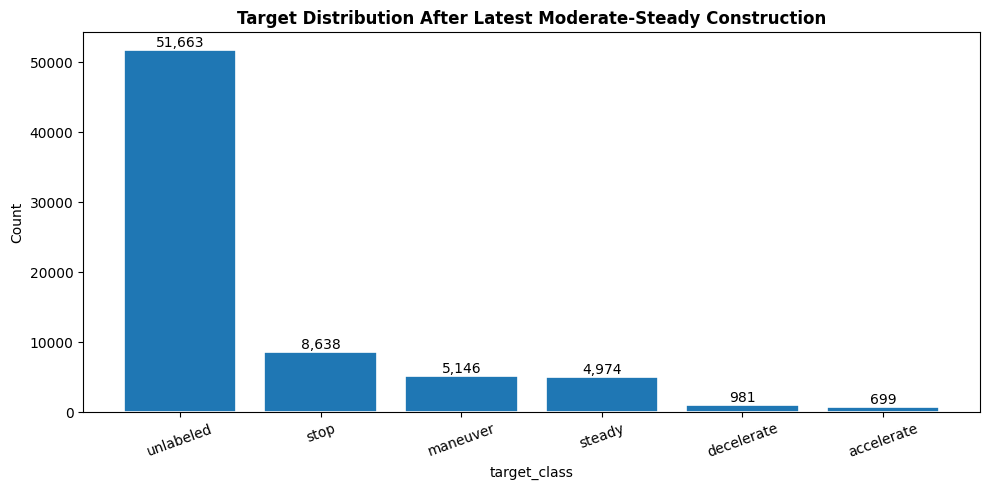

,target_class,count,proportion
0,unlabeled,51663,0.7165
1,stop,8638,0.1198
2,maneuver,5146,0.0714
3,steady,4974,0.0690
4,decelerate,981,0.0136
5,accelerate,699,0.0097


In [56]:
# =========================================================
# Target distribution visualization
# =========================================================
target_counts = target_df[TARGET_COL].value_counts(dropna=False)

labels = ["unlabeled" if pd.isna(x) else str(x) for x in target_counts.index]
values = target_counts.values

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:,}", ha="center", va="bottom", fontsize=10)

ax.set_title("Target Distribution After Latest Moderate-Steady Construction", fontweight="bold")
ax.set_xlabel("target_class")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

target_distribution_table = pd.DataFrame({
    "target_class": labels,
    "count": values,
    "proportion": (values / values.sum()).round(4)
})
display(target_distribution_table)


## 5.1 What changed compared with the older EDA target prototype?

The old EDA target prototype was useful for early exploration, but it no longer represents the final project pipeline.  
The final target construction differs in four important ways:

| Aspect | Earlier EDA prototype | Latest final logic |
|---|---|---|
| Time unit | raw AIS message windows | 10-minute vessel slices |
| Behavior classes | prototype classes such as cruise/stop-dwell | `steady`, `stop`, `accelerate`, `decelerate`, `maneuver` |
| Steady/cruise logic | closer to residual fallback | positive stable-moving evidence only |
| Invalid rows | most rows forced into a class | ambiguous rows can remain unlabeled and are excluded from model training |

This target update is important because it makes the modeling task more conservative and more diagnostically honest.


past_mean_rep_sog               future_mean_rep_sog               delta_mean_sog               future_stop_ratio                \
                         count   mean median               count   mean median          count   mean median             count   mean median   
target_class                                                                                                                                  
accelerate                 699  5.278   4.00                 699  9.405  8.000            699  4.126  3.150               699  0.010    0.0   
decelerate                 981  9.012   7.60                 981  4.522  3.000            981 -4.491 -3.275               981  0.120    0.0   
maneuver                  5146  4.391   2.65                5146  4.490  2.650           5146  0.100  0.000              5146  0.023    0.0   
steady                    4974  3.700   2.50                4974  3.697  2.475           4974 -0.004  0.000              4974  0.000    0.0   
stop                      8638  0.775   0.10                8638  0.114  0.100           8638 -0.661  0.000              8638  1.000    1.0   

             turn_change_deg_abs                   past_std_rep_sog               future_std_rep_sog                
                           count     mean   median            count   mean median              count   mean median  
target_class                                                                                                        
accelerate                   699   19.521   18.817              699  2.317   1.25                699  0.662  0.125  
decelerate                   838   18.825   17.123              981  0.873   0.15                981  1.769  0.525  
maneuver                    5146  110.575  105.999             5146  0.649   0.10               5146  0.635  0.100  
steady                      4973    9.967    6.775             4974  0.053   0.05               4974  0.054  0.050  
stop                           0      NaN      NaN             8638  0.290   0.00               8638  0.028  0.000

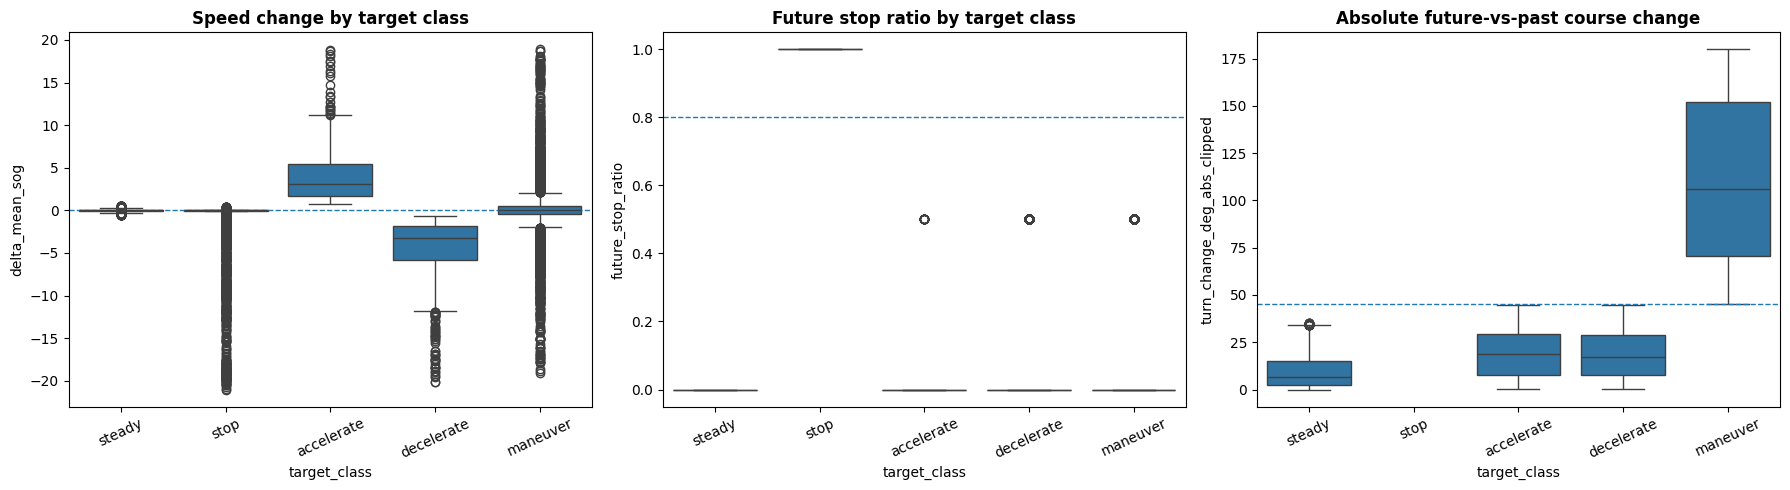

In [57]:
# =========================================================
# Target diagnostics by class
# =========================================================
labeled_target = target_df[target_df[TARGET_COL].notna()].copy()

diag_cols = [
    "past_mean_rep_sog",
    "future_mean_rep_sog",
    "delta_mean_sog",
    "future_stop_ratio",
    "turn_change_deg_abs",
    "past_std_rep_sog",
    "future_std_rep_sog",
]

diag_summary = (
    labeled_target
    .groupby(TARGET_COL)[diag_cols]
    .agg(["count", "mean", "median"])
    .round(3)
)

display(diag_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=labeled_target, x=TARGET_COL, y="delta_mean_sog", order=target_order, ax=axes[0])
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("Speed change by target class", fontweight="bold")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=labeled_target, x=TARGET_COL, y="future_stop_ratio", order=target_order, ax=axes[1])
axes[1].axhline(STOP_RATIO_THRESHOLD, linestyle="--", linewidth=1)
axes[1].set_title("Future stop ratio by target class", fontweight="bold")
axes[1].tick_params(axis="x", rotation=25)

plot_turn = labeled_target.copy()
plot_turn["turn_change_deg_abs_clipped"] = plot_turn["turn_change_deg_abs"].clip(upper=180)
sns.boxplot(data=plot_turn, x=TARGET_COL, y="turn_change_deg_abs_clipped", order=target_order, ax=axes[2])
axes[2].axhline(MANEUVER_TURN_THRESHOLD, linestyle="--", linewidth=1)
axes[2].set_title("Absolute future-vs-past course change", fontweight="bold")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


### Target diagnostics interpretation

The executed target diagnostics are aligned with the intended class definitions:

- `stop` has a mean and median `future_stop_ratio` of **1.0**, confirming that it represents near-stopped future behavior.
- `accelerate` has a positive mean `delta_mean_sog` of about **+4.13 knots**.
- `decelerate` has a negative mean `delta_mean_sog` of about **-4.49 knots**.
- `maneuver` has a much larger mean absolute course change, about **110.6 degrees**, than the other moving classes.
- `steady` has near-zero mean speed change, about **-0.004 knots**, low speed variability, and a median absolute course change of about **6.8 degrees**.

The high number of unlabeled rows is also expected. Empty slices, insufficient past/future context, and ambiguous motion patterns are deliberately excluded instead of being forced into a class. This is consistent with the updated target design where `steady` is not a residual/default label.


---
# 6. Leakage-Safe Model Feature Engineering

This EDA notebook also previews the model-feature design used in the latest data-preparation and training notebooks.

The key rule is:

<div class="warning">
Model features must use only current and past information.  
Future-window columns are allowed for target construction and diagnostics, but they must not be used as ordinary model input features.
</div>

The final model features include:

| Feature group | Examples |
|---|---|
| Current slice state | `rep_sog`, `rep_cog`, `sog_mean`, `sog_std`, `n_msgs`, `coverage_seconds` |
| Lagged slice state | `rep_sog_lag1`, `rep_cog_lag1`, `n_msgs_lag1`, etc. |
| Past-only motion change | `rep_sog_delta_1`, `rep_cog_diff_lag1` |
| Rolling local context | `rep_sog_roll2`, `rep_sog_roll3`, `coverage_roll3` |
| Stability features | `sog_stability_score`, `cog_stability_score`, `motion_stability_score`, `rep_sog_roll3_std` |
| Behavior trend features | `stop_tendency_score`, `maneuver_intensity_score` |
| Cyclical time features | `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos` |
| Reliability indicator | `cog_reliable` |

<div class="info">
This EDA preview follows the public 48-feature model-input design used by the DS2 preprocessing and training/evaluation notebooks. The binary `is_moving_steady_candidate` flag may still be displayed for diagnostics, but it is intentionally excluded from the final model input feature list.
</div>


In [58]:
# =========================================================
# Build leakage-safe modelling dataframe preview
# This mirrors the final preprocessing design, but keeps the EDA focus on inspection.
# =========================================================

# Constants used by the latest feature preparation
ZERO_SPEED_STEADY_REP_SOG_MAX = 0.10
ZERO_SPEED_STEADY_ROLL_MAX = 0.10
STRONG_MANEUVER_TURN_THRESHOLD_DEG = 60.0
EXTREME_MANEUVER_TURN_THRESHOLD_DEG = 90.0
STRONG_LAG_COG_JUMP_DEG = 90.0

STEADY_MIN_MOVING_SOG = 1.0
STEADY_MAX_ABS_SOG_DELTA = 0.45
STEADY_MAX_ABS_COG_DELTA = 30.0
STEADY_MAX_ROLL3_STD = 0.40
STEADY_MAX_MOTION_STABILITY_SCORE = 1.35


def _num_col(df, col, default=np.nan):
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(default, index=df.index, dtype="float64")


def add_behavior_rule_flags(df):
    df = df.copy()

    rep_sog = _num_col(df, "rep_sog")
    roll2 = _num_col(df, "rep_sog_roll2")
    roll3 = _num_col(df, "rep_sog_roll3")
    future_stop_ratio = _num_col(df, "future_stop_ratio")

    stop_by_ratio = future_stop_ratio.notna() & (future_stop_ratio >= STOP_RATIO_THRESHOLD)
    stop_by_zero_speed = (
        rep_sog.notna() &
        (rep_sog <= STOP_SOG_THRESHOLD) &
        (roll2.fillna(rep_sog) <= STOP_SOG_THRESHOLD) &
        (roll3.fillna(rep_sog) <= STOP_SOG_THRESHOLD)
    )
    df["is_stop_rule"] = stop_by_ratio | stop_by_zero_speed

    accel_threshold = _num_col(df, "accel_threshold_used")
    decel_threshold = _num_col(df, "decel_threshold_used")
    delta_mean_sog = _num_col(df, "delta_mean_sog")

    d1 = _num_col(df, "rep_sog_delta_1")
    d2 = _num_col(df, "rep_sog_delta_2")
    fallback_delta = pd.concat([d1, d2], axis=1)

    effective_accel_delta = delta_mean_sog.fillna(fallback_delta.max(axis=1))
    effective_decel_delta = delta_mean_sog.fillna(fallback_delta.min(axis=1))

    df["is_accel_rule"] = (
        effective_accel_delta.notna() &
        accel_threshold.notna() &
        (effective_accel_delta >= accel_threshold)
    )
    df["is_decel_rule"] = (
        effective_decel_delta.notna() &
        decel_threshold.notna() &
        (effective_decel_delta <= -decel_threshold)
    )

    turn_change = _num_col(df, "turn_change_deg_abs")
    df["is_maneuver_rule"] = (
        turn_change.notna() &
        rep_sog.notna() &
        (rep_sog >= MIN_VALID_COG_SOG) &
        (turn_change >= MANEUVER_TURN_THRESHOLD)
    )

    lag1 = _num_col(df, "rep_cog_diff_lag1").abs()
    lag2 = _num_col(df, "rep_cog_diff_lag2").abs()
    df["strong_lag_cog_jump_flag"] = (
        (rep_sog >= MIN_VALID_COG_SOG) &
        ((lag1 >= STRONG_LAG_COG_JUMP_DEG) | (lag2 >= STRONG_LAG_COG_JUMP_DEG))
    )

    rule_cols = ["is_stop_rule", "is_accel_rule", "is_decel_rule", "is_maneuver_rule"]
    df["rule_overlap_count"] = df[rule_cols].sum(axis=1)

    def _signature(row):
        parts = []
        if row["is_stop_rule"]:
            parts.append("STOP")
        if row["is_accel_rule"]:
            parts.append("ACCEL")
        if row["is_decel_rule"]:
            parts.append("DECEL")
        if row["is_maneuver_rule"]:
            parts.append("MANEUVER")
        return "+".join(parts) if parts else "STEADY"

    df["rule_signature"] = df.apply(_signature, axis=1)

    df["maneuver_strength_bin"] = pd.cut(
        turn_change,
        bins=[
            -np.inf,
            MANEUVER_TURN_THRESHOLD,
            STRONG_MANEUVER_TURN_THRESHOLD_DEG,
            EXTREME_MANEUVER_TURN_THRESHOLD_DEG,
            np.inf,
        ],
        labels=["below_threshold", "borderline_45_60", "strong_60_90", "extreme_gt_90"],
    )

    df["cog_reliable"] = (rep_sog >= MIN_VALID_COG_SOG).astype(int)
    return df


def repair_zero_speed_steady_labels_in_model_df(df):
    df = df.copy()

    steady_code = target_map.get("steady")
    stop_code = target_map.get("stop")

    rep_sog = _num_col(df, "rep_sog")
    roll2 = _num_col(df, "rep_sog_roll2")
    roll3 = _num_col(df, "rep_sog_roll3")

    near_zero_speed = (
        (rep_sog <= ZERO_SPEED_STEADY_REP_SOG_MAX) &
        (roll2.fillna(rep_sog) <= ZERO_SPEED_STEADY_ROLL_MAX) &
        (roll3.fillna(rep_sog) <= ZERO_SPEED_STEADY_ROLL_MAX)
    )

    current_is_steady = df[TARGET_COL].astype(str).eq("steady")
    repair_mask = current_is_steady & near_zero_speed

    df["zero_speed_steady_repaired_to_stop"] = repair_mask

    n_repaired = int(repair_mask.sum())
    if n_repaired > 0:
        df.loc[repair_mask, TARGET_COL] = "stop"
        df.loc[repair_mask, "target_code"] = stop_code

    return df, n_repaired


def add_past_current_stability_features(df):
    """
    Add positive steady-motion and trend features using only current/past information.

    The final deployable model uses the continuous 48-feature set. The earlier
    binary `is_moving_steady_candidate` is retained only for EDA/diagnostic
    inspection and is intentionally excluded from the model feature list.
    """
    df = df.copy()

    d1 = _num_col(df, "rep_sog_delta_1")
    d2 = _num_col(df, "rep_sog_delta_2")
    c1 = _num_col(df, "rep_cog_diff_lag1")
    c2 = _num_col(df, "rep_cog_diff_lag2")
    rep_sog = _num_col(df, "rep_sog")

    df["abs_rep_sog_delta_1"] = d1.abs()
    df["abs_rep_sog_delta_2"] = d2.abs()
    df["abs_rep_cog_diff_lag1"] = c1.abs()
    df["abs_rep_cog_diff_lag2"] = c2.abs()

    df["sog_stability_score"] = (
        df["abs_rep_sog_delta_1"].fillna(0) +
        df["abs_rep_sog_delta_2"].fillna(0)
    )

    df["cog_stability_score"] = (
        df["abs_rep_cog_diff_lag1"].fillna(0) +
        df["abs_rep_cog_diff_lag2"].fillna(0)
    )

    df["motion_stability_score"] = df["sog_stability_score"] + 0.02 * df["cog_stability_score"]

    df["rep_sog_roll3_std"] = (
        df.groupby(MMSI_COL)["rep_sog"]
          .transform(lambda x: x.rolling(window=3, min_periods=1).std())
    )

    cog_reliable_series = (
        df["cog_reliable"].astype(int)
        if "cog_reliable" in df.columns
        else (rep_sog >= MIN_VALID_COG_SOG).astype(int)
    )

    strong_jump_series = (
        df["strong_lag_cog_jump_flag"].astype(int)
        if "strong_lag_cog_jump_flag" in df.columns
        else pd.Series(0, index=df.index, dtype="int64")
    )

    roll3_std = pd.to_numeric(df["rep_sog_roll3_std"], errors="coerce")
    motion_score = pd.to_numeric(df["motion_stability_score"], errors="coerce")

    # Diagnostic-only flag. It is useful for inspecting steady-motion evidence,
    # but it is not included as a final model input feature.
    df["is_moving_steady_candidate"] = (
        (rep_sog >= STEADY_MIN_MOVING_SOG) &
        (df["abs_rep_sog_delta_1"].fillna(0) <= STEADY_MAX_ABS_SOG_DELTA) &
        (df["abs_rep_sog_delta_2"].fillna(0) <= STEADY_MAX_ABS_SOG_DELTA) &
        (df["abs_rep_cog_diff_lag1"].fillna(0) <= STEADY_MAX_ABS_COG_DELTA) &
        (df["abs_rep_cog_diff_lag2"].fillna(0) <= STEADY_MAX_ABS_COG_DELTA) &
        (roll3_std.fillna(0) <= STEADY_MAX_ROLL3_STD) &
        (motion_score.fillna(np.inf) <= STEADY_MAX_MOTION_STABILITY_SCORE) &
        (strong_jump_series == 0) &
        (cog_reliable_series == 1)
    ).astype(int)

    # Final inference-safe behavior trend features used by the 48-feature model.
    # These replace the earlier binary moving-steady candidate as model input and
    # use only current/past values available at inference time.
    eps = 0.1
    rep_sog_roll3 = _num_col(df, "rep_sog_roll3")
    stop_tendency = (rep_sog_roll3 - rep_sog) / (rep_sog_roll3 + eps)
    df["stop_tendency_score"] = (
        stop_tendency
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .clip(-5.0, 5.0)
    )

    maneuver_intensity = c1.abs() / (1.0 + d1.abs())
    df["maneuver_intensity_score"] = (
        maneuver_intensity
        .where(cog_reliable_series.astype(int).eq(1), 0.0)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .clip(0.0, 180.0)
    )

    return df

def mask_low_speed_cog_features(df, feature_cols):
    df = df.copy()

    if "cog_reliable" not in df.columns:
        df["cog_reliable"] = (_num_col(df, "rep_sog") >= MIN_VALID_COG_SOG).astype(int)

    if "cog_reliable" not in feature_cols:
        feature_cols = feature_cols + ["cog_reliable"]

    cog_feature_cols = [
        c for c in feature_cols
        if (
            c != "cog_reliable"
            and (
                "cog" in c.lower()
                or "turn" in c.lower()
                or "heading" in c.lower()
                or "course" in c.lower()
            )
        )
    ]

    low_speed_mask = df["cog_reliable"].astype(int).eq(0)
    if cog_feature_cols and low_speed_mask.any():
        df.loc[low_speed_mask, cog_feature_cols] = 0.0

    return df, feature_cols, cog_feature_cols, int(low_speed_mask.sum())


In [59]:
# =========================================================
# Create model-ready preview dataframe
# =========================================================
model_df = target_df.copy()
model_df = model_df.sort_values([MMSI_COL, "slice_start"]).reset_index(drop=True)

model_df = model_df[
    model_df[TARGET_COL].notna() &
    model_df["has_data"] &
    model_df["enough_data_for_repr"]
].copy()

# Lag features per vessel
for lag in range(1, N_LAGS + 1):
    for col in ["rep_sog", "rep_cog", "n_msgs", "coverage_seconds", "cog_valid_for_maneuver"]:
        model_df[f"{col}_lag{lag}"] = model_df.groupby(MMSI_COL)[col].shift(lag)

# Past-only derived features
model_df["rep_sog_delta_1"] = model_df["rep_sog"] - model_df["rep_sog_lag1"]
model_df["rep_sog_delta_2"] = model_df["rep_sog_lag1"] - model_df["rep_sog_lag2"]

model_df["rep_cog_diff_lag1"] = circular_diff_series_deg(model_df["rep_cog"], model_df["rep_cog_lag1"])
model_df["rep_cog_diff_lag2"] = circular_diff_series_deg(model_df["rep_cog_lag1"], model_df["rep_cog_lag2"])

model_df["rep_sog_roll2"] = (
    model_df.groupby(MMSI_COL)["rep_sog"]
    .transform(lambda s: s.rolling(window=2, min_periods=1).mean())
)

model_df["rep_sog_roll3"] = (
    model_df.groupby(MMSI_COL)["rep_sog"]
    .transform(lambda s: s.rolling(window=3, min_periods=1).mean())
)

model_df["n_msgs_roll3"] = (
    model_df.groupby(MMSI_COL)["n_msgs"]
    .transform(lambda s: s.rolling(window=3, min_periods=1).mean())
)

model_df["coverage_roll3"] = (
    model_df.groupby(MMSI_COL)["coverage_seconds"]
    .transform(lambda s: s.rolling(window=3, min_periods=1).mean())
)

# Repair the clearest label contradiction found during diagnostics.
model_df, n_zero_speed_steady_repaired = repair_zero_speed_steady_labels_in_model_df(model_df)

# Rule overlap diagnostics
model_df = add_behavior_rule_flags(model_df)

# Current/past stability features
model_df = add_past_current_stability_features(model_df)

# Time features
model_df["hour"] = model_df["slice_start"].dt.hour
model_df["dayofweek"] = model_df["slice_start"].dt.dayofweek
model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24.0)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24.0)
model_df["dow_sin"] = np.sin(2 * np.pi * model_df["dayofweek"] / 7.0)
model_df["dow_cos"] = np.cos(2 * np.pi * model_df["dayofweek"] / 7.0)

feature_cols = [
    # base
    "rep_sog",
    "rep_cog",
    "sog_mean",
    "sog_std",
    "sog_min",
    "sog_max",
    "cog_circular_std",
    "n_msgs",
    "coverage_seconds",
    "cog_valid_for_maneuver",

    # lags
    "rep_sog_lag1", "rep_sog_lag2", "rep_sog_lag3",
    "rep_cog_lag1", "rep_cog_lag2", "rep_cog_lag3",
    "n_msgs_lag1", "n_msgs_lag2", "n_msgs_lag3",
    "coverage_seconds_lag1", "coverage_seconds_lag2", "coverage_seconds_lag3",
    "cog_valid_for_maneuver_lag1", "cog_valid_for_maneuver_lag2", "cog_valid_for_maneuver_lag3",

    # derived
    "rep_sog_delta_1",
    "rep_sog_delta_2",
    "rep_cog_diff_lag1",
    "rep_cog_diff_lag2",
    "rep_sog_roll2",
    "rep_sog_roll3",
    "n_msgs_roll3",
    "coverage_roll3",

    # steady/stability features: current/past only
    "abs_rep_sog_delta_1",
    "abs_rep_sog_delta_2",
    "abs_rep_cog_diff_lag1",
    "abs_rep_cog_diff_lag2",
    "sog_stability_score",
    "cog_stability_score",
    "motion_stability_score",
    "rep_sog_roll3_std",
    "stop_tendency_score",
    "maneuver_intensity_score",

    # time
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
]

bool_like_cols = [
    "cog_valid_for_maneuver",
    "cog_valid_for_maneuver_lag1",
    "cog_valid_for_maneuver_lag2",
    "cog_valid_for_maneuver_lag3",
    "strong_lag_cog_jump_flag",
    "zero_speed_steady_repaired_to_stop",
    "is_stop_rule",
    "is_accel_rule",
    "is_decel_rule",
    "is_maneuver_rule",
    "is_moving_steady_candidate",
]

for col in bool_like_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(False).astype("int64")

# Low-speed COG masking
model_df, feature_cols, masked_cog_feature_cols, low_speed_cog_masked_rows = mask_low_speed_cog_features(model_df, feature_cols)

for col in feature_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df["target_code"] = model_df["target_code"].astype(int)

print("model_df:", model_df.shape)
print("Feature count:", len(feature_cols))
print("Zero-speed steady labels repaired to stop:", n_zero_speed_steady_repaired)
print("Low-speed rows with COG-derived features masked:", low_speed_cog_masked_rows)

print("\nClass distribution after feature-preparation repairs:")
display(model_df[TARGET_COL].value_counts(normalize=True).round(4).to_frame("proportion"))

print("\nRule signature distribution:")
display(model_df["rule_signature"].value_counts().head(15).to_frame("count"))

feature_audit = pd.DataFrame([
    {"check": "Final feature count", "expected": 48, "actual": len(feature_cols), "passed": len(feature_cols) == 48},
    {"check": "stop_tendency_score included", "expected": True, "actual": "stop_tendency_score" in feature_cols, "passed": "stop_tendency_score" in feature_cols},
    {"check": "maneuver_intensity_score included", "expected": True, "actual": "maneuver_intensity_score" in feature_cols, "passed": "maneuver_intensity_score" in feature_cols},
    {"check": "cog_reliable included", "expected": True, "actual": "cog_reliable" in feature_cols, "passed": "cog_reliable" in feature_cols},
    {"check": "diagnostic steady flag excluded", "expected": False, "actual": "is_moving_steady_candidate" in feature_cols, "passed": "is_moving_steady_candidate" not in feature_cols},
    {"check": "future-window columns excluded", "expected": False, "actual": any(("future" in c.lower()) for c in feature_cols), "passed": not any(("future" in c.lower()) for c in feature_cols)},
])
print("\nFinal feature audit:")
display(feature_audit)


model_df: (19772, 90)
Feature count: 48
Zero-speed steady labels repaired to stop: 0
Low-speed rows with COG-derived features masked: 8477

Class distribution after feature-preparation repairs:


,proportion
target_class,
stop,0.4226
maneuver,0.2484
steady,0.2454
decelerate,0.0488
accelerate,0.0348



Rule signature distribution:


,count
rule_signature,
STOP,7657
STEADY,4934
MANEUVER,2931
DECEL,1056
ACCEL+MANEUVER,912
DECEL+MANEUVER,781
ACCEL,779
STOP+DECEL,706
STOP+ACCEL,16



Final feature audit:


,check,expected,actual,passed
0,Final feature count,48,48,True
1,stop_tendency_score included,True,True,True
2,maneuver_intensity_score included,True,True,True
3,cog_reliable included,True,True,True
4,diagnostic steady flag excluded,False,False,True
5,future-window columns excluded,False,False,True


In [60]:
# =========================================================
# Preview final modeling columns
# =========================================================
preview_cols = [c for c in [
    MMSI_COL, "slice_start", "slice_end", TARGET_COL, "target_code",
    "rule_signature", "speed_regime",
    "rep_sog", "rep_sog_lag1", "rep_sog_lag2",
    "rep_sog_delta_1", "rep_sog_delta_2",
    "rep_cog", "rep_cog_lag1", "rep_cog_diff_lag1",
    "rep_sog_roll2", "rep_sog_roll3", "rep_sog_roll3_std",
    "sog_stability_score", "cog_stability_score", "motion_stability_score",
    "stop_tendency_score", "maneuver_intensity_score",
    "is_moving_steady_candidate", "cog_reliable"
] if c in model_df.columns]

display(model_df[preview_cols].head(20))


,MMSI,slice_start,slice_end,target_class,target_code,rule_signature,speed_regime,rep_sog,rep_sog_lag1,rep_sog_lag2,rep_sog_delta_1,rep_sog_delta_2,rep_cog,rep_cog_lag1,rep_cog_diff_lag1,rep_sog_roll2,rep_sog_roll3,rep_sog_roll3_std,sog_stability_score,cog_stability_score,motion_stability_score,stop_tendency_score,maneuver_intensity_score,is_moving_steady_candidate,cog_reliable
1,338115852,2023-01-10 20:00:00,2023-01-10 20:10:00,steady,0,STEADY,mid,8.15,NaN,NaN,NaN,NaN,292.250015,NaN,NaN,8.150,8.150000,NaN,0.00,0.000000,0.000000,0.000000,0.000000,1,1
2,338115852,2023-01-10 20:10:00,2023-01-10 20:20:00,steady,0,STEADY,mid,8.10,8.15,NaN,-0.05,NaN,292.966160,292.250015,0.716145,8.125,8.125000,0.035355,0.05,0.716145,0.064323,0.003040,0.682043,1,1
5,338115852,2023-01-10 20:40:00,2023-01-10 20:50:00,steady,0,STEADY,mid,7.40,8.10,8.15,-0.70,-0.05,290.399866,292.966160,-2.566294,7.750,7.883333,0.419325,0.75,3.282439,0.815649,0.060543,1.509585,0,1
6,338115852,2023-01-10 20:50:00,2023-01-10 21:00:00,steady,0,STEADY,mid,7.40,7.40,8.10,0.00,-0.70,291.494585,290.399866,1.094719,7.400,7.633333,0.404145,0.70,3.661013,0.773220,0.030172,1.094719,0,1
7,338115852,2023-01-10 21:00:00,2023-01-10 21:10:00,steady,0,STEADY,mid,7.45,7.40,7.40,0.05,0.00,300.484374,291.494585,8.989790,7.425,7.416667,0.028868,0.05,10.084509,0.251690,-0.004435,8.561705,1,1
8,338115852,2023-01-10 21:10:00,2023-01-10 21:20:00,steady,0,STEADY,mid,7.55,7.45,7.40,0.10,0.05,297.945609,300.484374,-2.538765,7.500,7.466667,0.076376,0.15,11.528555,0.380571,-0.011013,2.307968,1,1
9,338115852,2023-01-10 21:20:00,2023-01-10 21:30:00,steady,0,STEADY,mid,7.35,7.55,7.45,-0.20,0.10,292.199615,297.945609,-5.745994,7.450,7.450000,0.100000,0.30,8.284759,0.465695,0.013245,4.788328,1,1
10,338115852,2023-01-10 21:30:00,2023-01-10 21:40:00,steady,0,STEADY,mid,7.10,7.35,7.55,-0.25,-0.20,302.745967,292.199615,10.546352,7.225,7.333333,0.225462,0.45,16.292346,0.775847,0.031390,8.437082,1,1
12,338115852,2023-01-10 21:50:00,2023-01-10 22:00:00,steady,0,STEADY,mid,7.90,7.10,7.35,0.80,-0.25,297.414532,302.745967,-5.331435,7.500,7.450000,0.409268,1.05,15.877787,1.367556,-0.059603,2.961908,0,1
13,338115852,2023-01-10 22:00:00,2023-01-10 22:10:00,steady,0,STEADY,mid,7.90,7.90,7.10,0.00,0.80,289.855565,297.414532,-7.558967,7.900,7.633333,0.461880,0.80,12.890403,1.057808,-0.034483,7.558967,0,1


## 6.1 Feature relationship checks

After constructing the model features, the EDA checks whether core features align with the target classes.  
The goal is not to prove model performance here, but to confirm that the engineered variables carry meaningful signal for behavior classification.


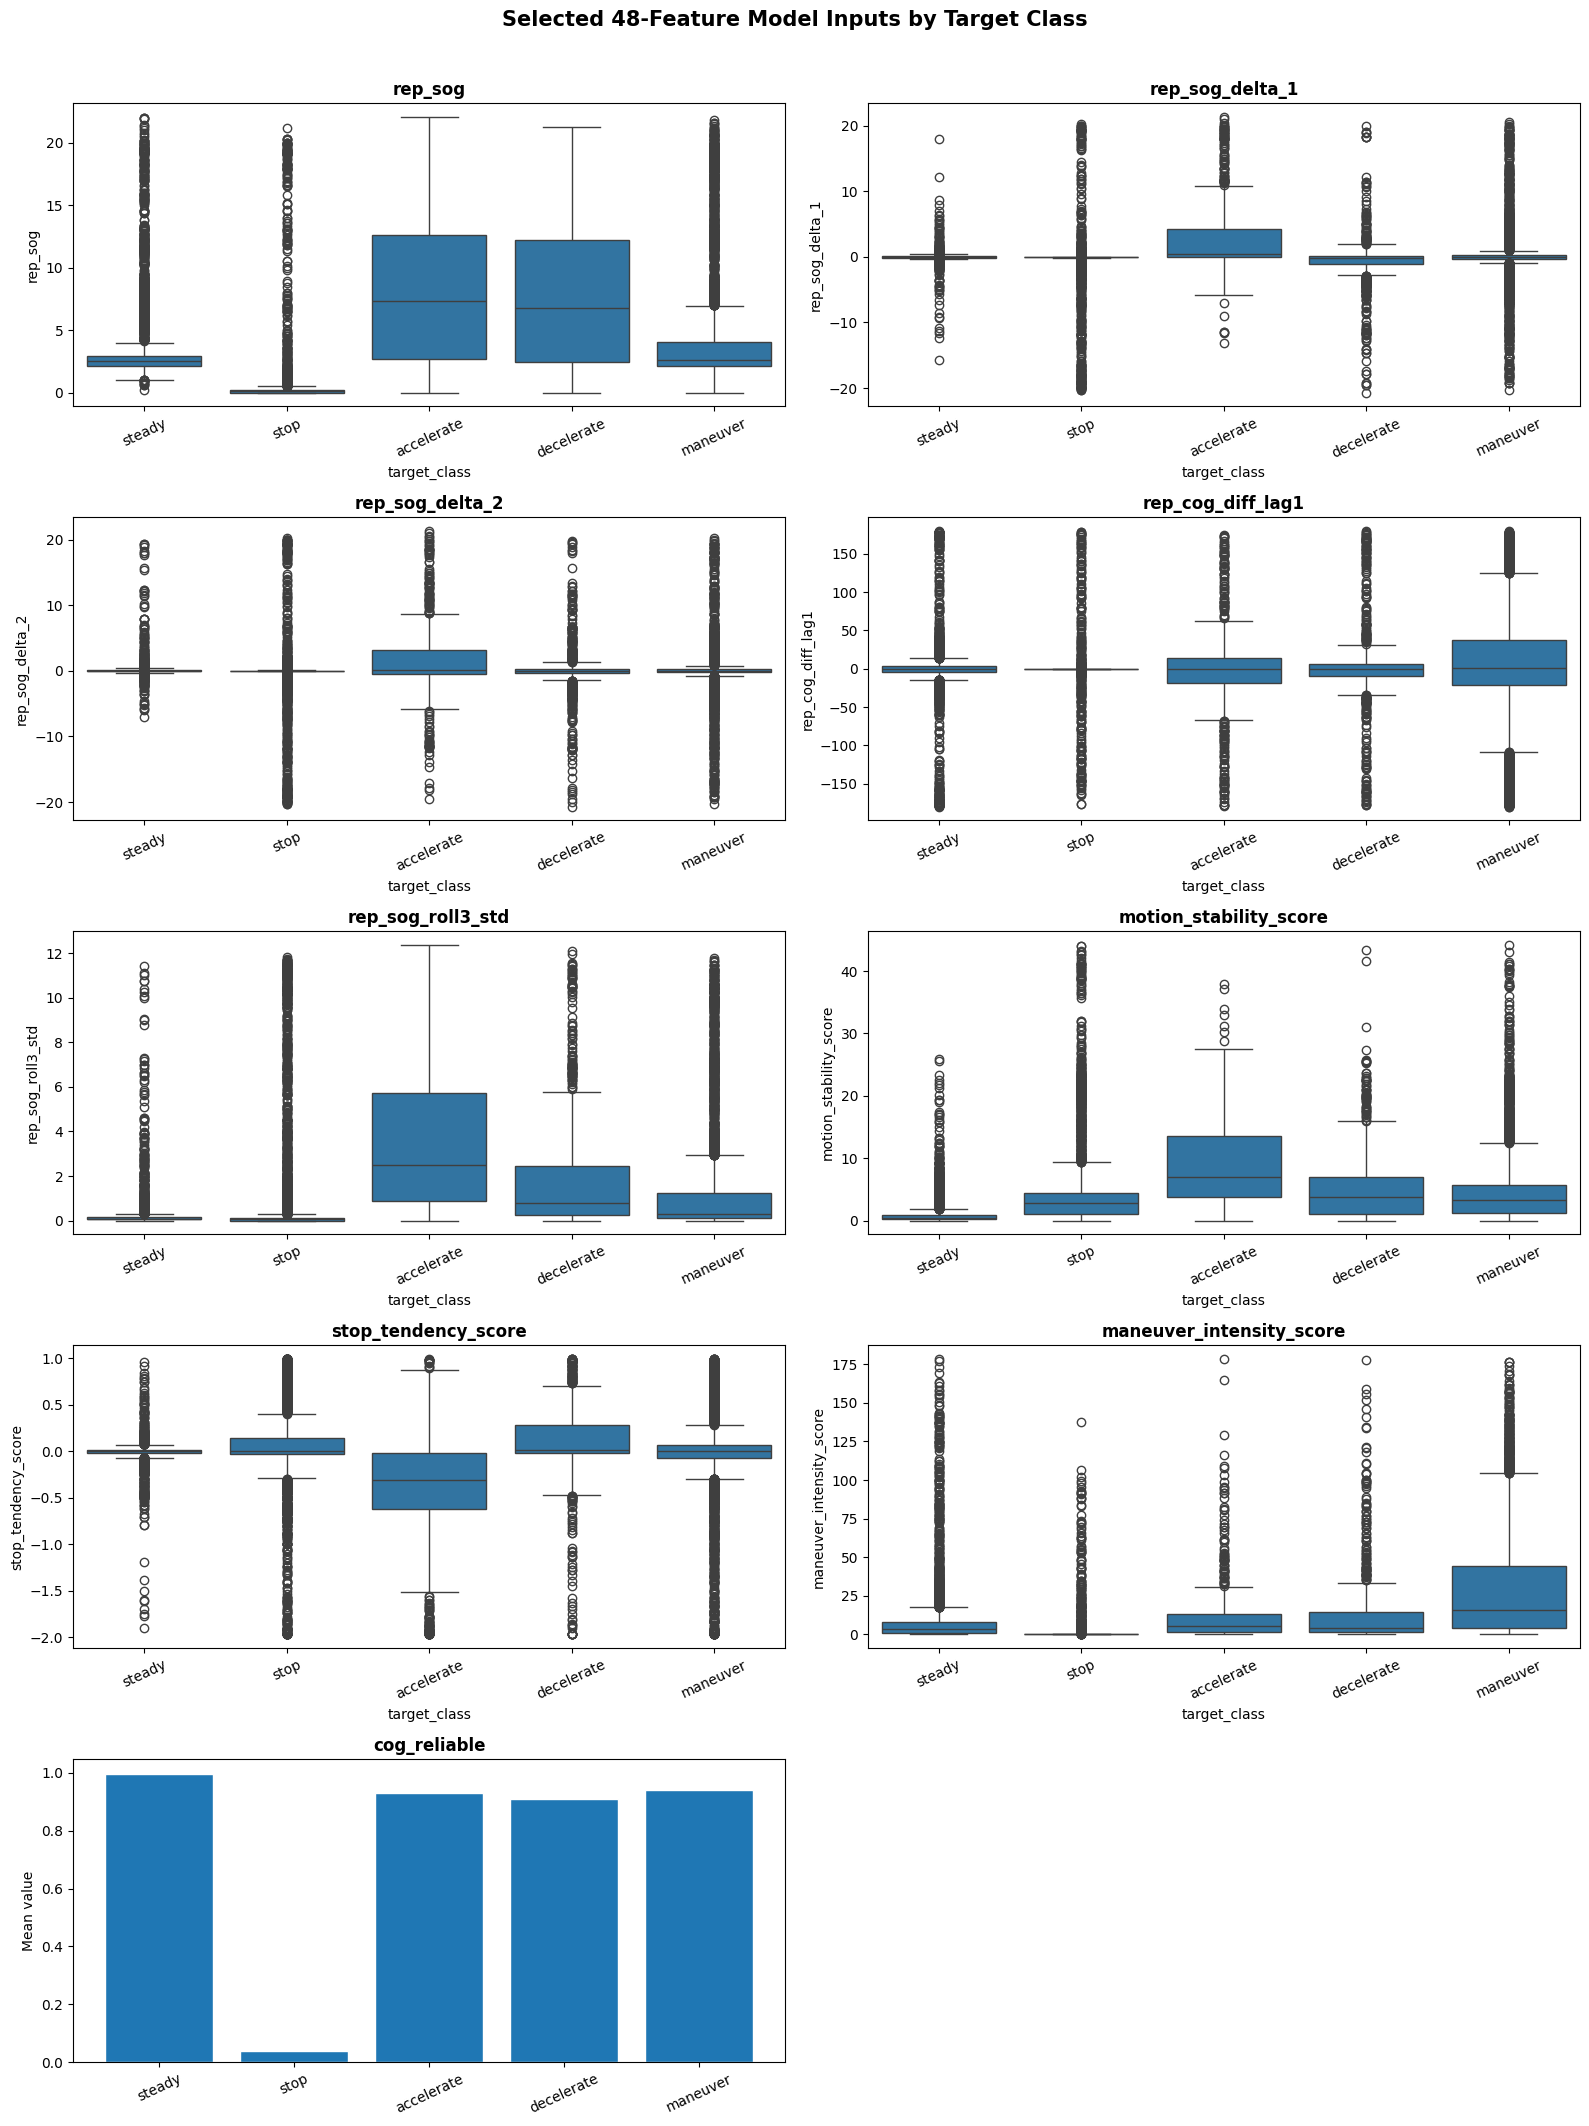

In [61]:
# =========================================================
# Feature distributions by target class
# =========================================================
plot_features = [
    "rep_sog",
    "rep_sog_delta_1",
    "rep_sog_delta_2",
    "rep_cog_diff_lag1",
    "rep_sog_roll3_std",
    "motion_stability_score",
    "stop_tendency_score",
    "maneuver_intensity_score",
    "cog_reliable",
]
plot_features = [c for c in plot_features if c in model_df.columns]

ncols = 2
nrows = int(np.ceil(len(plot_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.2 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, plot_features):
    plot_data = model_df[[TARGET_COL, col]].copy()
    if plot_data[col].nunique(dropna=True) <= 2:
        means = plot_data.groupby(TARGET_COL)[col].mean().reindex(target_order)
        ax.bar(means.index, means.values, edgecolor="white")
        ax.set_ylabel("Mean value")
    else:
        sns.boxplot(data=plot_data, x=TARGET_COL, y=col, order=target_order, ax=ax)
    ax.set_title(col, fontweight="bold")
    ax.tick_params(axis="x", rotation=25)

for j in range(len(plot_features), len(axes)):
    axes[j].axis("off")

fig.suptitle("Selected 48-Feature Model Inputs by Target Class", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


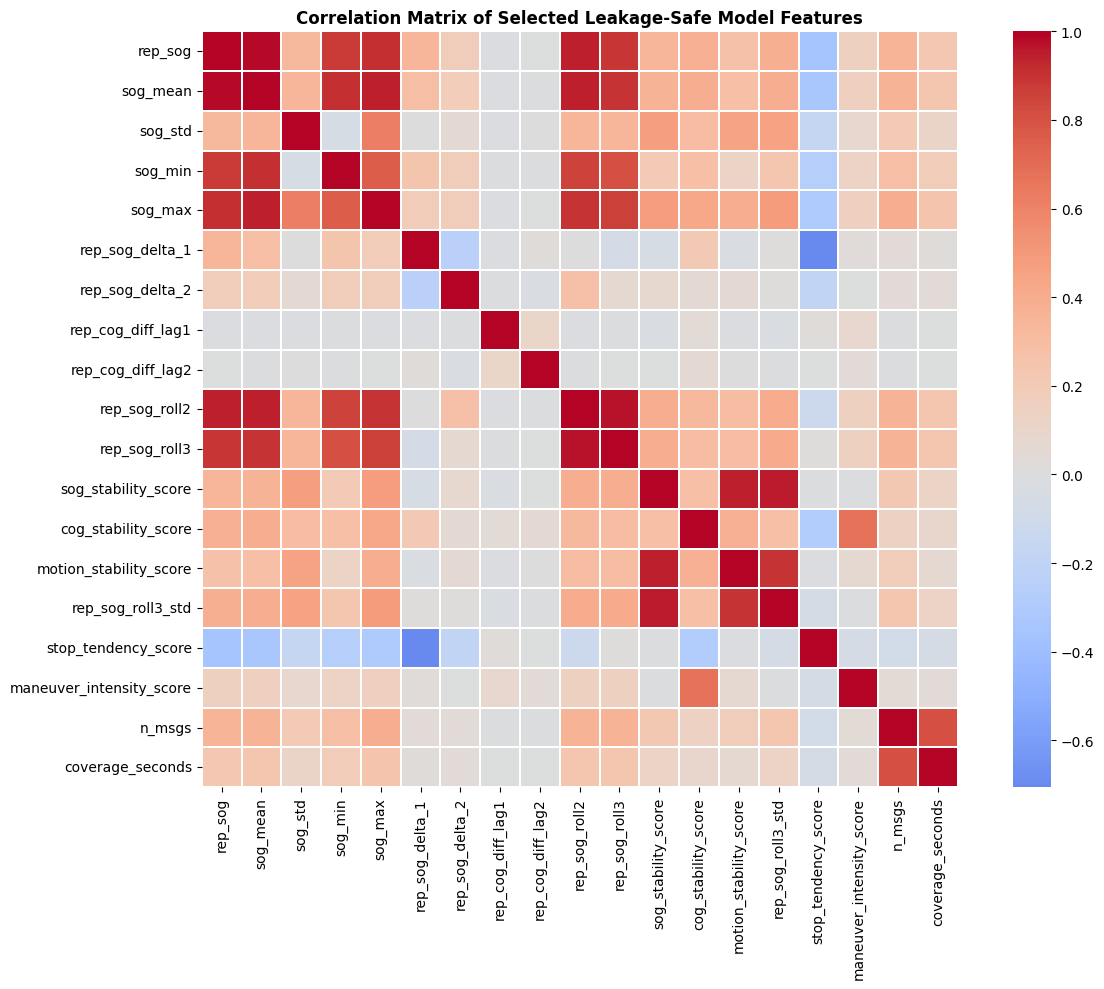

,feature_1,feature_2,correlation,abs_correlation
0,rep_sog,sog_mean,0.986022,0.986022
126,rep_sog_roll2,rep_sog_roll3,0.970173,0.970173
145,sog_stability_score,rep_sog_roll3_std,0.954404,0.954404
25,sog_mean,rep_sog_roll2,0.944377,0.944377
144,sog_stability_score,motion_stability_score,0.940538,0.940538
20,sog_mean,sog_max,0.940403,0.940403
8,rep_sog,rep_sog_roll2,0.940366,0.940366
3,rep_sog,sog_max,0.906742,0.906742
19,sog_mean,sog_min,0.906466,0.906466
26,sog_mean,rep_sog_roll3,0.899310,0.899310


In [62]:
# =========================================================
# Correlation analysis for leakage-safe numeric model features
# =========================================================
corr_features = [
    "rep_sog",
    "sog_mean",
    "sog_std",
    "sog_min",
    "sog_max",
    "rep_sog_delta_1",
    "rep_sog_delta_2",
    "rep_cog_diff_lag1",
    "rep_cog_diff_lag2",
    "rep_sog_roll2",
    "rep_sog_roll3",
    "sog_stability_score",
    "cog_stability_score",
    "motion_stability_score",
    "rep_sog_roll3_std",
    "stop_tendency_score",
    "maneuver_intensity_score",
    "n_msgs",
    "coverage_seconds",
]
corr_features = [c for c in corr_features if c in model_df.columns]

corr_df = model_df[corr_features].apply(pd.to_numeric, errors="coerce")
corr = corr_df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True, linewidths=0.3)
plt.title("Correlation Matrix of Selected Leakage-Safe Model Features", fontweight="bold")
plt.tight_layout()
plt.show()

# Show strongest absolute correlations, excluding self-correlations.
pairs = []
for i, c1 in enumerate(corr.columns):
    for c2 in corr.columns[i+1:]:
        val = corr.loc[c1, c2]
        if pd.notna(val):
            pairs.append({"feature_1": c1, "feature_2": c2, "correlation": val, "abs_correlation": abs(val)})

display(pd.DataFrame(pairs).sort_values("abs_correlation", ascending=False).head(15))


### Feature engineering interpretation

The final feature set is consistent with the project goal because it describes **motion context**, not only the current AIS message.

The DS1 feature-preview run is intended to mirror the final DS2 model-input design. It should therefore report **48 leakage-safe candidate features**: current-slice features, past-only lag/rolling features, stability scores, time encodings, `cog_reliable`, and the two final inference-safe behavior trend features `stop_tendency_score` and `maneuver_intensity_score`.

The resulting class mix after feature preparation is summarized in the executed output above. The most important conceptual improvements are:

- `rep_sog_delta_*` captures short-term speed changes.
- `rep_cog_diff_*` captures circular direction changes.
- rolling speed features capture local movement context.
- stability scores give the model explicit evidence for the revised `steady` class.
- `stop_tendency_score` describes whether the current speed is dropping relative to the recent rolling speed context.
- `maneuver_intensity_score` describes recent course-change intensity while remaining current/past-only.
- `cog_reliable` protects the model from over-interpreting course changes at very low speeds.
- `is_moving_steady_candidate` is retained only as a diagnostic/inspection flag and is intentionally excluded from the final model feature list.
- future-window target diagnostics are kept separate from model input features to avoid leakage.

The correlation matrix shows several intentionally related speed-summary features, such as `rep_sog`, `sog_mean`, and rolling SOG features. This is acceptable for the tree-based models used in the training notebook, but it should be considered if a simpler linear model is later introduced.


---
# 7. EDA Findings and Handoff to Training/Evaluation

## Main findings from the DS1 EDA run

1. **The AIS data is trajectory-based**, so rows cannot be treated as independent observations without temporal context.
2. **Heading has a major AIS placeholder issue**: in DS1, about **99.06%** of rows have `Heading = 511`, meaning unknown heading.
3. **COG is circular and speed-dependent**. The DS1 run also shows a large `COG = 360` boundary-value issue, so COG cleaning and low-speed masking are necessary.
4. **10-minute slice aggregation** creates a stable unit for behavior labeling and modeling. In DS1, this produced **72,101** vessel-slice rows.
5. **Many slice rows are intentionally unlabeled**. About **71.65%** of slice rows remain unlabeled because empty slices, insufficient context, and ambiguous cases are excluded rather than forced into a class.
6. **The updated `steady` logic is stricter and more defensible** because it requires explicit stable-motion evidence. The diagnostics confirm near-zero speed change and low course change for `steady` rows.
7. **Model features are leakage-safe** because they use only current and past slice information. Future-window columns are used only for target construction and diagnostics.
8. **Class imbalance remains important**. After model-feature filtering, `accelerate` and `decelerate` are still minority classes, which justifies the balanced-training strategy used later.

## Scope note

This EDA notebook uses DS1 to keep exploratory analysis lightweight and executable.  
The final preprocessing and training/evaluation notebooks use DS2, so all final model-performance claims should be based on DS2 results.

## Handoff to the training/evaluation notebook

The next notebook should start from the persisted train/validation/test files created by the DS2 preprocessing notebook. The latest training/evaluation notebook uses the balanced training folder by default:

```text
ais_ds2_prepared/balanced_train/
```

The unbalanced/original final split is also available in:

```text
ais_ds2_prepared/final/
```

The final training/evaluation notebook uses:

- MMSI-held-out validation and test sets,
- balanced training data only for model fitting,
- original validation/test distributions for honest evaluation,
- class-wise metrics, confusion matrix, and error diagnosis.


In [63]:
# =========================================================
# Optional: persist EDA-generated intermediate files
# =========================================================
SAVE_EDA_OUTPUTS = False

if SAVE_EDA_OUTPUTS:
    EDA_OUTPUT_DIR = Path("./eda_target_updated_outputs")
    EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    slice_level_df.to_csv(EDA_OUTPUT_DIR / "slice_level_df_eda.csv", index=False)
    target_df.to_csv(EDA_OUTPUT_DIR / "target_df_eda.csv", index=False)
    model_df.to_csv(EDA_OUTPUT_DIR / "model_df_eda_preview.csv", index=False)

    with open(EDA_OUTPUT_DIR / "feature_cols_eda_preview.json", "w") as f:
        json.dump(feature_cols, f, indent=2)

    print("Saved EDA outputs to:", EDA_OUTPUT_DIR)
else:
    print("SAVE_EDA_OUTPUTS is False. No files were written.")


SAVE_EDA_OUTPUTS is False. No files were written.


---
## Pipeline Summary

<div class="success">
EDA and target construction have been updated to match the latest data-preparation and training/evaluation pipeline.  
The EDA run uses DS1 for speed, while the final model pipeline remains on DS2.
</div>

| Stage | Output |
|---|---|
| Raw AIS EDA on DS1 | schema, missingness, distributions, AIS-specific issues |
| Trajectory preparation | ordered MMSI/time structure and time-gap diagnostics |
| Slice-level representation | 10-minute vessel slices |
| Target construction | latest 5-class moderate-steady logic |
| Feature engineering preview | leakage-safe current/past model features |
| Training handoff | DS2 prepared data folder and model-evaluation strategy |
